# Capstone Project: Time Series Analysis 2026
## Data-Driven Stock Forecasting and Virtual Portfolio Management on StockGro

| Detail | Value |
|--------|-------|
| Trading Window | Day 1: Thursday, 14 May 2026 — Day 2: Friday, 15 May 2026 |
| Virtual Capital | Rs. 10,00,000 |
| Platform | StockGro (Portfolio - Time Series Analysis 2026) |
| Evaluation Dataset | Train: Jan 2021 to Dec 2025, Test: Jan to Mar 2026 |
| Prediction Dataset | Full retrain on Jan 2021 to 13 May 2026, forecast next 5 trading days |

---

### Methodology Overview

This project uses two separate datasets to keep evaluation and forecasting completely isolated:

- **Dataset A** is used purely for model evaluation. Models are trained on data up to December 2025 and tested on January to March 2026. This gives us unbiased MAPE, RMSE, and directional accuracy numbers.

- **Dataset B** is used for actual forecasting. Once we are satisfied with model performance on Dataset A, we retrain all models on the complete available data (up to 13 May 2026) and generate 5-day price forecasts starting from 14 May 2026. These forecasts directly inform our portfolio construction and trade decisions.

---

### Tasks
1. Stock Universe Selection
2. Data Preprocessing
3. Time Series Forecasting — ARIMA, Prophet, LSTM
4. Volatility and Trend Analysis
5. Portfolio Construction and Capital Allocation
6. Model Comparison
7. Virtual Trading on StockGro
8. Performance Tracking and Comparison

## Setup and Installation

In [1]:
!pip install yfinance prophet statsmodels scikit-learn tensorflow keras arch seaborn matplotlib pandas numpy --quiet 2>/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 25.4 MB/s eta 0:00:00


In [2]:
# Suppress all warnings and TensorFlow logs before importing anything.
# This keeps the notebook output clean and readable.
import os, sys, logging, warnings

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL']   = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS']  = '0'
os.environ['PYTHONWARNINGS']          = 'ignore'
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('pystan').setLevel(logging.ERROR)
logging.getLogger('yfinance').setLevel(logging.ERROR)
logging.getLogger('peewee').setLevel(logging.ERROR)
logging.getLogger('urllib3').setLevel(logging.ERROR)
logging.getLogger('arch').setLevel(logging.ERROR)
logging.disable(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import itertools

import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL

from prophet import Prophet

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from arch import arch_model

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Task 1: Stock Universe Selection

We selected five stocks spread across five major NSE sectors to ensure adequate diversification. The selection was driven by three criteria: rolling standard deviation to understand each stock's volatility profile, STL decomposition to identify those with strong underlying trends, and sector-level rationale to minimise correlation between holdings.

| Stock | Ticker | Sector | Rationale |
|-------|--------|--------|-----------|
| HDFC Bank | HDFCBANK.NS | Banking | Largest private sector bank; stable long-term trend with moderate volatility |
| Infosys | INFY.NS | IT | Strong sector momentum driven by global IT spending; clear seasonal patterns |
| Sun Pharma | SUNPHARMA.NS | Pharma | Low correlation with broader market; acts as a defensive position |
| Hindustan Unilever | HINDUNILVR.NS | FMCG | Consistently low volatility; predictable trend; reliable for conservative allocation |
| Maruti Suzuki | MARUTI.NS | Auto | Market leader in passenger vehicles; strong revenue visibility; good vol profile for GARCH modelling |

In [3]:
# Central configuration for all datasets, date ranges, and capital.
# Changing any of these values will propagate through the entire notebook.

STOCKS = {
    'HDFCBANK':   'HDFCBANK.NS',
    'INFY':       'INFY.NS',
    'SUNPHARMA':  'SUNPHARMA.NS',
    'HINDUNILVR': 'HINDUNILVR.NS',
    'MARUTI':     'MARUTI.NS'
}

SECTORS = {
    'HDFCBANK':   'Banking',
    'INFY':       'IT',
    'SUNPHARMA':  'Pharma',
    'HINDUNILVR': 'FMCG',
    'MARUTI':     'Auto'
}

# Dataset A is used only for model evaluation (MAPE, RMSE, directional accuracy)
A_START      = '2021-01-01'
A_TRAIN_END  = '2025-12-31'
A_TEST_START = '2026-01-01'
A_END        = '2026-03-31'

# Dataset B is used for final forecasting after full retraining
B_START      = '2021-01-01'
B_END        = '2026-05-13'

TOTAL_CAPITAL = 1_000_000
FORECAST_DAYS = 5
LOOKBACK      = 60

print('Configuration summary:')
print(f'  Stocks          : {list(STOCKS.keys())}')
print(f'  Dataset A Train : {A_START} to {A_TRAIN_END}')
print(f'  Dataset A Test  : {A_TEST_START} to {A_END}')
print(f'  Dataset B       : {B_START} to {B_END} (full retrain, no test split)')
print(f'  Forecast horizon: {FORECAST_DAYS} trading days')
print(f'  Virtual capital : Rs. {TOTAL_CAPITAL:,.0f}')

Configuration summary:
  Stocks          : ['HDFCBANK', 'INFY', 'SUNPHARMA', 'HINDUNILVR', 'MARUTI']
  Dataset A Train : 2021-01-01 to 2025-12-31
  Dataset A Test  : 2026-01-01 to 2026-03-31
  Dataset B       : 2021-01-01 to 2026-05-13 (full retrain, no test split)
  Forecast horizon: 5 trading days
  Virtual capital : Rs. 1,000,000


In [4]:
# Utility function to download data from Yahoo Finance.
# Handles the MultiIndex column issue introduced in newer versions of yfinance,
# and strips timezone information from the index so date comparisons work cleanly.

def fetch(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    if df.empty:
        raise ValueError(f'No data returned for {ticker}. Check the ticker or date range.')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    if isinstance(df['Close'], pd.DataFrame):
        df['Close'] = df['Close'].iloc[:, 0]
    df.index = pd.to_datetime(df.index).tz_localize(None).normalize()
    return df[['Close']].ffill().bfill()

print('Fetching Dataset A (2021 to March 2026)...')
raw_A = {}
for name, ticker in STOCKS.items():
    raw_A[name] = fetch(ticker, A_START, A_END)
    print(f'  {name}: {len(raw_A[name])} trading days')

print('\nFetching Dataset B (2021 to 13 May 2026, used for final forecasting)...')
raw_B = {}
for name, ticker in STOCKS.items():
    raw_B[name] = fetch(ticker, B_START, B_END)
    print(f'  {name}: {len(raw_B[name])} trading days')

print('\nAll data fetched successfully.')

Fetching Dataset A (2021 to March 2026)...
  HDFCBANK: 1296 trading days
  INFY: 1296 trading days
  SUNPHARMA: 1296 trading days
  HINDUNILVR: 1296 trading days
  MARUTI: 1296 trading days

Fetching Dataset B (2021 to 13 May 2026, used for final forecasting)...
  HDFCBANK: 1324 trading days
  INFY: 1324 trading days
  SUNPHARMA: 1324 trading days
  HINDUNILVR: 1324 trading days
  MARUTI: 1324 trading days

All data fetched successfully.


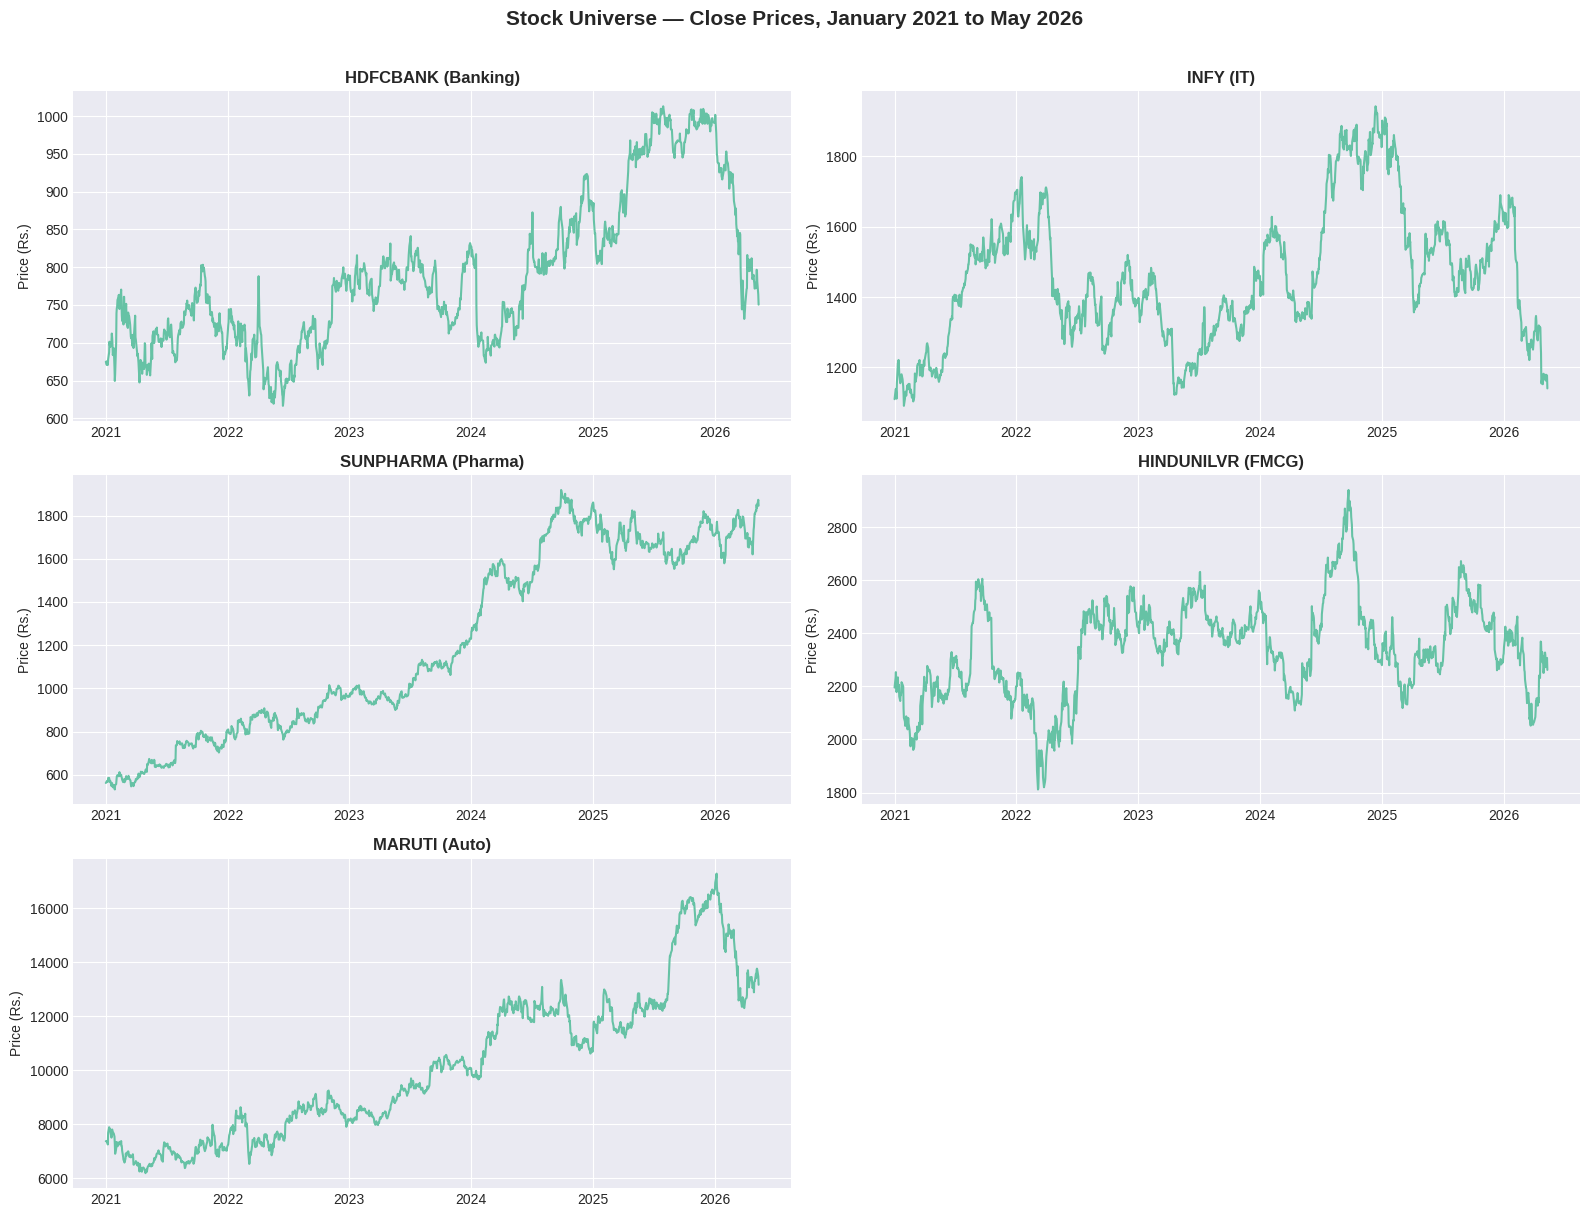

In [5]:
# Historical close price chart for all five stocks.
# This gives a visual sense of long-term trends and major drawdowns before we start modelling.

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()
for i, (name, df) in enumerate(raw_B.items()):
    axes[i].plot(df.index, df['Close'], lw=1.5)
    axes[i].set_title(f'{name} ({SECTORS[name]})', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Price (Rs.)')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_visible(False)
plt.suptitle('Stock Universe — Close Prices, January 2021 to May 2026',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stock_prices.png', dpi=150, bbox_inches='tight')
plt.show()

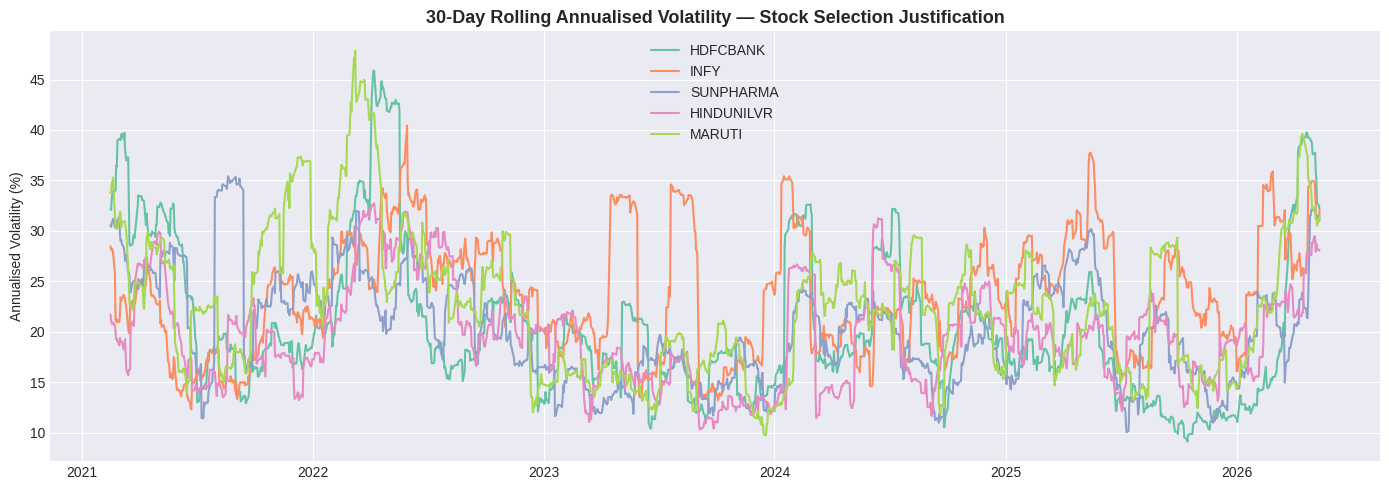

In [6]:
# 30-day rolling annualised volatility is one of the key criteria we used to select
# stocks for the portfolio. Stocks with persistently high volatility were deprioritised
# unless their return outlook was strong enough to justify the risk.

fig, ax = plt.subplots(figsize=(14, 5))
for name, df in raw_B.items():
    rv = df['Close'].pct_change().dropna().rolling(30).std() * np.sqrt(252) * 100
    ax.plot(rv.index, rv, label=name, lw=1.5)
ax.set_title('30-Day Rolling Annualised Volatility — Stock Selection Justification',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Annualised Volatility (%)')
ax.legend()
plt.tight_layout()
plt.savefig('rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 2: Data Preprocessing

In [7]:
# Build the processed versions of both datasets.
# For Dataset A we create a Train/Test split column based on the cutoff date.
# For Dataset B all rows are training data since we retrain on the full history.

A_TRAIN_END_TS = pd.Timestamp(A_TRAIN_END).normalize()

proc_A = {}
proc_B = {}

print('Dataset A — Train/Test split:')
for name, df in raw_A.items():
    d = df.copy()
    d.index = pd.to_datetime(d.index).normalize()
    d['Log_Return'] = np.log(d['Close'] / d['Close'].shift(1))
    d['Split'] = np.where(d.index <= A_TRAIN_END_TS, 'Train', 'Test')
    n_tr = (d['Split'] == 'Train').sum()
    n_te = (d['Split'] == 'Test').sum()
    assert n_tr > 0 and n_te > 0, f'Date split failed for {name}. Check A_TRAIN_END.'
    proc_A[name] = d
    print(f'  {name}: {n_tr} training rows, {n_te} test rows')

print('\nDataset B — Full training set (no test split):')
for name, df in raw_B.items():
    d = df.copy()
    d.index = pd.to_datetime(d.index).normalize()
    d['Log_Return'] = np.log(d['Close'] / d['Close'].shift(1))
    proc_B[name] = d
    print(f'  {name}: {len(d)} rows')

print('\nPreprocessing complete.')

Dataset A — Train/Test split:
  HDFCBANK: 1236 training rows, 60 test rows
  INFY: 1236 training rows, 60 test rows
  SUNPHARMA: 1236 training rows, 60 test rows
  HINDUNILVR: 1236 training rows, 60 test rows
  MARUTI: 1236 training rows, 60 test rows

Dataset B — Full training set (no test split):
  HDFCBANK: 1324 rows
  INFY: 1324 rows
  SUNPHARMA: 1324 rows
  HINDUNILVR: 1324 rows
  MARUTI: 1324 rows

Preprocessing complete.


In [8]:
# Augmented Dickey-Fuller test to check stationarity.
# Most time series models assume stationarity. Stock prices in levels are almost
# always non-stationary, but first-differencing (d=1) typically makes them stationary.
# We use this to justify our choice of d=1 in ARIMA.

def adf_test(series, label=''):
    clean = series.dropna()
    if len(clean) < 10:
        print(f'  {label:<25} Not enough observations ({len(clean)})')
        return False
    res = adfuller(clean)
    p   = res[1]
    tag = 'Stationary' if p < 0.05 else 'Non-stationary'
    print(f'  {label:<25} ADF={res[0]:8.4f}  p-value={p:.4f}  -> {tag}')
    return p < 0.05

stationarity = {}
print('ADF Test on Raw Close Prices (Dataset A, training period only):')
for name, df in proc_A.items():
    stationarity[name] = adf_test(df[df['Split']=='Train']['Close'], name)

print('\nADF Test after First-Differencing:')
for name, df in proc_A.items():
    adf_test(df[df['Split']=='Train']['Close'].diff().dropna(), f'{name} (differenced)')

print('\nConclusion: Prices are non-stationary in levels but stationary after first differencing.')
print('This confirms d=1 is the appropriate differencing order for ARIMA.')

ADF Test on Raw Close Prices (Dataset A, training period only):
  HDFCBANK                  ADF= -1.3937  p-value=0.5853  -> Non-stationary
  INFY                      ADF= -2.4072  p-value=0.1397  -> Non-stationary
  SUNPHARMA                 ADF= -0.8510  p-value=0.8037  -> Non-stationary
  HINDUNILVR                ADF= -2.8895  p-value=0.0466  -> Stationary
  MARUTI                    ADF=  0.5026  p-value=0.9850  -> Non-stationary

ADF Test after First-Differencing:
  HDFCBANK (differenced)    ADF=-14.0414  p-value=0.0000  -> Stationary
  INFY (differenced)        ADF=-34.0530  p-value=0.0000  -> Stationary
  SUNPHARMA (differenced)   ADF=-10.1151  p-value=0.0000  -> Stationary
  HINDUNILVR (differenced)  ADF=-35.1409  p-value=0.0000  -> Stationary
  MARUTI (differenced)      ADF=-24.9797  p-value=0.0000  -> Stationary

Conclusion: Prices are non-stationary in levels but stationary after first differencing.
This confirms d=1 is the appropriate differencing order for ARIMA.


In [9]:
# Normalise data for LSTM using MinMaxScaler.
# Important: the scaler for Dataset A is fitted only on training data, never on test data.
# Fitting on the full series would allow the model to indirectly see future price ranges
# during training, which would inflate performance metrics (data leakage).
# For Dataset B, all data is training data, so the scaler is fitted on the full series.

scalers_A  = {}
scaled_A   = {}
scalers_B  = {}
scaled_B   = {}

for name in STOCKS:
    df_a        = proc_A[name]
    train_a     = df_a[df_a['Split']=='Train']['Close'].values.reshape(-1, 1)
    all_a       = df_a['Close'].values.reshape(-1, 1)
    sc_a        = MinMaxScaler(feature_range=(0, 1))
    sc_a.fit(train_a)
    scalers_A[name] = sc_a
    scaled_A[name]  = sc_a.transform(all_a)

    all_b       = proc_B[name]['Close'].values.reshape(-1, 1)
    sc_b        = MinMaxScaler(feature_range=(0, 1))
    sc_b.fit(all_b)
    scalers_B[name] = sc_b
    scaled_B[name]  = sc_b.transform(all_b)

    print(f'  {name}: Dataset A training rows = {len(train_a)}, Dataset B total rows = {len(all_b)}')

print('\nNormalisation complete. No data leakage introduced.')

  HDFCBANK: Dataset A training rows = 1236, Dataset B total rows = 1324
  INFY: Dataset A training rows = 1236, Dataset B total rows = 1324
  SUNPHARMA: Dataset A training rows = 1236, Dataset B total rows = 1324
  HINDUNILVR: Dataset A training rows = 1236, Dataset B total rows = 1324
  MARUTI: Dataset A training rows = 1236, Dataset B total rows = 1324

Normalisation complete. No data leakage introduced.


---
## Task 3: Time Series Forecasting

Each model goes through two passes:
- **Evaluation Pass (Dataset A):** Train on 2021-2025, test on Jan-Mar 2026. Produces MAPE, RMSE, and directional accuracy for model comparison.
- **Forecast Pass (Dataset B):** Retrain on all available data up to 13 May 2026. Produces the 5-day price forecast used for portfolio construction.

### 3A. ARIMA

In [10]:
# Helper function to compute forecast accuracy metrics.
# MAPE tells us average percentage error, RMSE tells us average absolute error in rupees,
# and directional accuracy tells us how often the model got the direction of price movement right.

def compute_metrics(actual, predicted, model_name=''):
    a = np.array(actual).flatten()
    p = np.array(predicted).flatten()
    mape = np.mean(np.abs((a - p) / a)) * 100
    rmse = np.sqrt(mean_squared_error(a, p))
    da   = np.mean(np.sign(np.diff(a)) == np.sign(np.diff(p))) * 100
    return {'Model': model_name, 'MAPE (%)': round(mape, 3),
            'RMSE': round(rmse, 3), 'Dir Acc (%)': round(da, 1)}

In [11]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

# ARIMA order selection using AIC minimisation.
def best_arima_order(series):
    best_aic, best_order = np.inf, (1, 1, 1)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ValueWarning)
        warnings.simplefilter("ignore", ConvergenceWarning)
        warnings.filterwarnings("ignore")

        for p, d, q in itertools.product(range(4), range(2), range(4)):
            try:
                res = ARIMA(series, order=(p, d, q)).fit()
                if res.aic < best_aic:
                    best_aic, best_order = res.aic, (p, d, q)
            except:
                continue

    return best_order, best_aic

arima_orders = {}
print('Selecting best ARIMA orders by AIC (this typically takes 2 to 3 minutes)...')

for name, df in proc_A.items():
    order, aic = best_arima_order(df[df['Split']=='Train']['Close'])
    arima_orders[name] = order
    print(f'  {name}: best order = {order}, AIC = {aic:.2f}')

print('\nARIMA order selection complete!')

Selecting best ARIMA orders by AIC (this typically takes 2 to 3 minutes)...
  HDFCBANK: best order = (3, 1, 3), AIC = 9233.18
  INFY: best order = (0, 1, 0), AIC = 11177.82
  SUNPHARMA: best order = (3, 1, 3), AIC = 10264.40
  HINDUNILVR: best order = (0, 1, 0), AIC = 11856.54
  MARUTI: best order = (2, 1, 0), AIC = 15725.07

ARIMA order selection complete!


In [12]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

# ARIMA Evaluation Pass — fit on Dataset A training data, predict on test period.
arima_results_A = {}
arima_metrics_A = []

# Mute all statsmodels warnings specifically for this cell
warnings.simplefilter('ignore', ValueWarning)
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.filterwarnings("ignore")

for name, df in proc_A.items():
    train = df[df['Split']=='Train']['Close']
    test  = df[df['Split']=='Test']['Close']

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = ARIMA(train, order=arima_orders[name]).fit()

    start_idx = len(train)
    end_idx   = len(train) + len(test) - 1
    preds = model.predict(start=start_idx, end=end_idx)

    # Re-attach the correct dates to the predictions
    preds.index = test.index

    arima_results_A[name] = {'actual': test, 'predicted': preds}
    m = compute_metrics(test.values, preds.values, 'ARIMA')
    m['Stock'] = name
    arima_metrics_A.append(m)
    print(f'  {name}: MAPE = {m["MAPE (%)"]:.2f}%,  RMSE = {m["RMSE"]:.2f},  Directional Accuracy = {m["Dir Acc (%)"]:.1f}%')

print('\nARIMA evaluation complete.')

  HDFCBANK: MAPE = 11.18%,  RMSE = 113.07,  Directional Accuracy = 44.1%
  INFY: MAPE = 14.13%,  RMSE = 233.87,  Directional Accuracy = 1.7%
  SUNPHARMA: MAPE = 2.99%,  RMSE = 64.37,  Directional Accuracy = 45.8%
  HINDUNILVR: MAPE = 4.09%,  RMSE = 114.79,  Directional Accuracy = 1.7%
  MARUTI: MAPE = 14.05%,  RMSE = 2327.58,  Directional Accuracy = 16.9%

ARIMA evaluation complete.


In [13]:
# ARIMA Forecast Pass — retrain on Dataset B (full history) and forecast 5 days ahead.

arima_forecasts_B = {}

for name, df in proc_B.items():
    model = ARIMA(df['Close'], order=arima_orders[name]).fit()
    fc    = model.forecast(steps=FORECAST_DAYS)
    arima_forecasts_B[name] = fc.values.tolist()
    fstr = ',  '.join([f'Day {i+1} = Rs. {v:.2f}' for i, v in enumerate(fc.values)])
    print(f'  {name}: {fstr}')

print('\nARIMA 5-day forecasts generated.')

  HDFCBANK: Day 1 = Rs. 751.39,  Day 2 = Rs. 750.48,  Day 3 = Rs. 752.31,  Day 4 = Rs. 752.36,  Day 5 = Rs. 751.93
  INFY: Day 1 = Rs. 1140.30,  Day 2 = Rs. 1140.30,  Day 3 = Rs. 1140.30,  Day 4 = Rs. 1140.30,  Day 5 = Rs. 1140.30
  SUNPHARMA: Day 1 = Rs. 1850.23,  Day 2 = Rs. 1845.43,  Day 3 = Rs. 1846.75,  Day 4 = Rs. 1850.21,  Day 5 = Rs. 1845.39
  HINDUNILVR: Day 1 = Rs. 2262.00,  Day 2 = Rs. 2262.00,  Day 3 = Rs. 2262.00,  Day 4 = Rs. 2262.00,  Day 5 = Rs. 2262.00
  MARUTI: Day 1 = Rs. 13156.36,  Day 2 = Rs. 13166.10,  Day 3 = Rs. 13167.41,  Day 4 = Rs. 13167.17,  Day 5 = Rs. 13167.10

ARIMA 5-day forecasts generated.


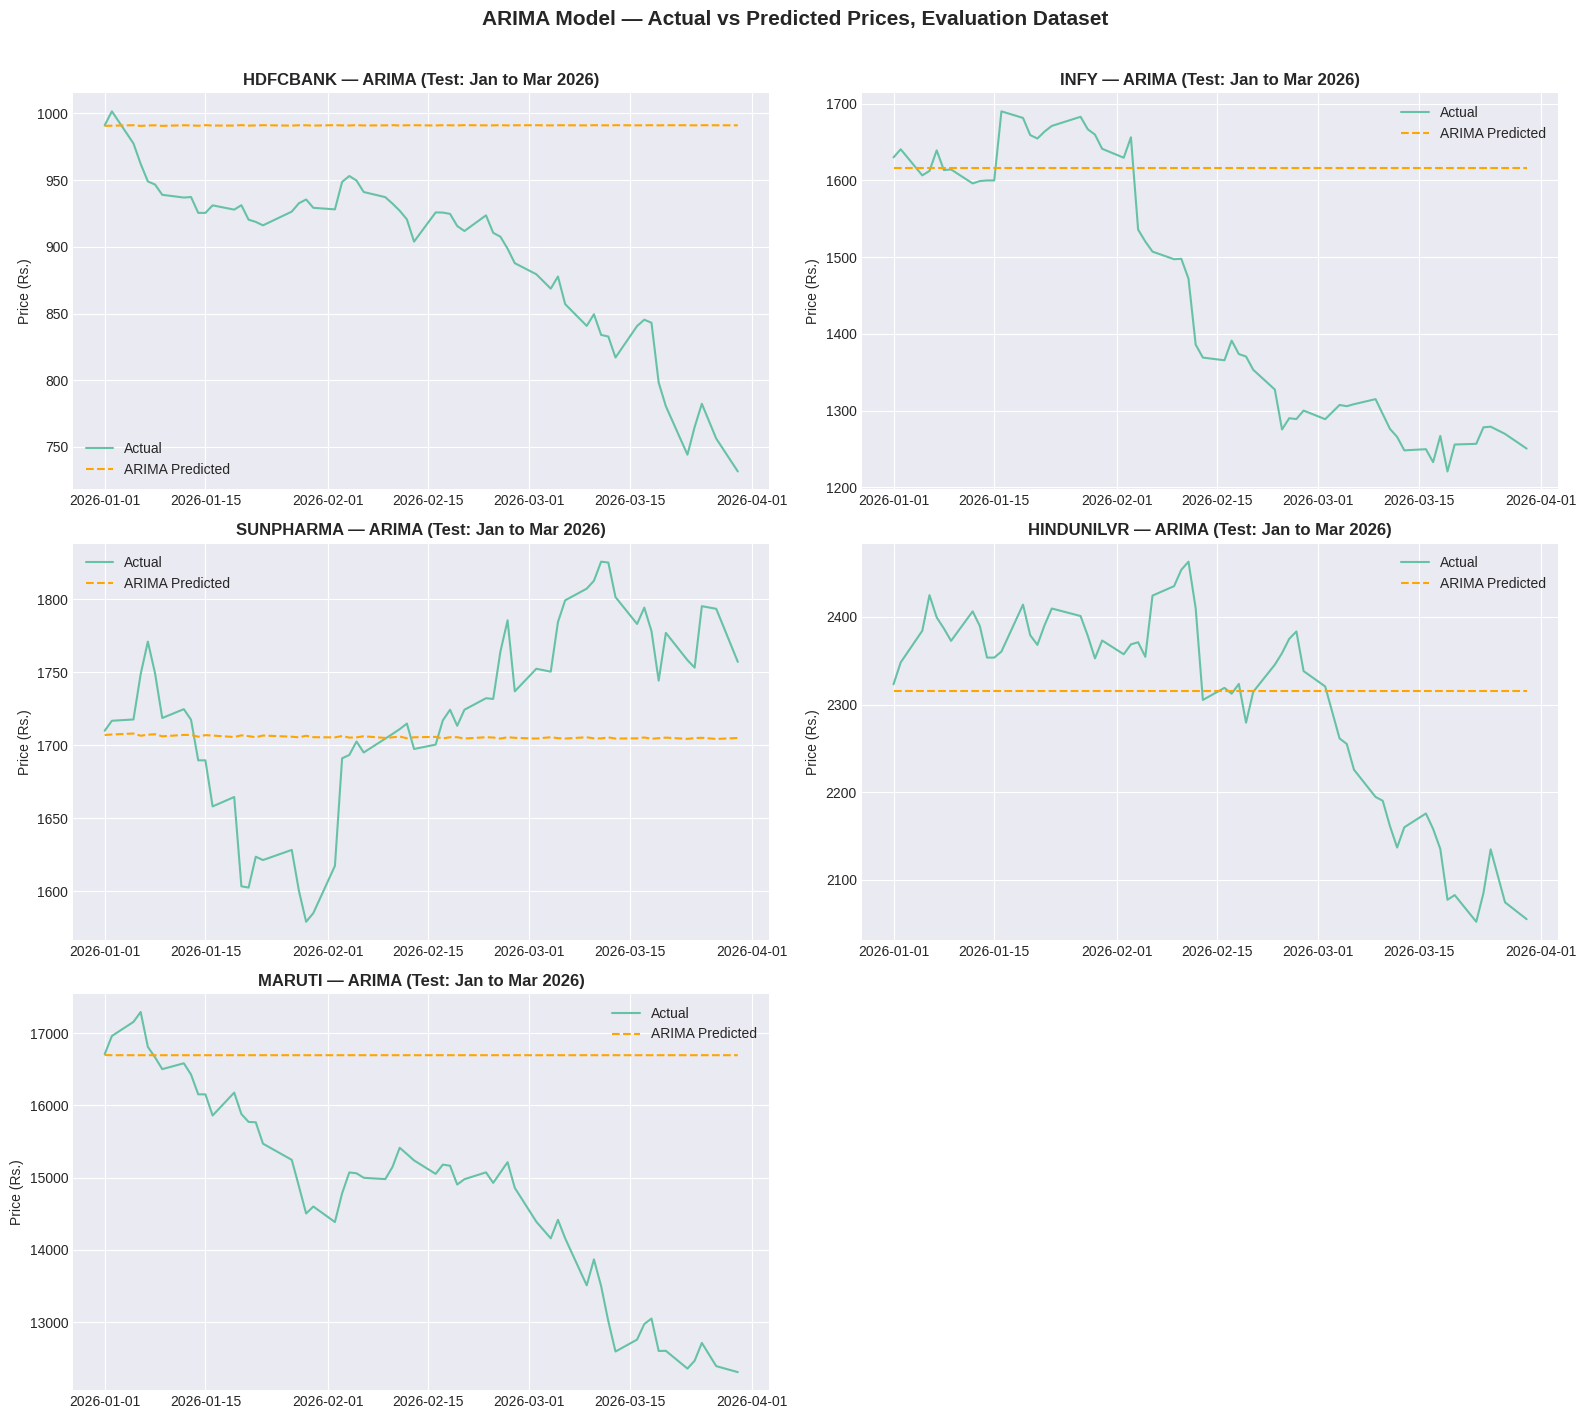

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()
for i, (name, res) in enumerate(arima_results_A.items()):
    axes[i].plot(res['actual'].index,    res['actual'].values,    label='Actual',          lw=1.5)
    axes[i].plot(res['predicted'].index, res['predicted'].values, label='ARIMA Predicted', lw=1.5, ls='--', color='orange')
    axes[i].set_title(f'{name} — ARIMA (Test: Jan to Mar 2026)', fontweight='bold')
    axes[i].set_ylabel('Price (Rs.)')
    axes[i].legend()
axes[-1].set_visible(False)
plt.suptitle('ARIMA Model — Actual vs Predicted Prices, Evaluation Dataset',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('arima_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3B. Prophet

In [15]:
# Prophet Evaluation Pass.
# Prophet is particularly well-suited for financial time series because it natively
# handles weekly and yearly seasonality and is robust to missing values and outliers.
# The changepoint_prior_scale parameter controls how flexible the trend is;
# a lower value (0.05) prevents overfitting to short-term noise.

prophet_results_A = {}
prophet_metrics_A = []

for name, df in proc_A.items():
    train_df = df[df['Split']=='Train']['Close'].reset_index()
    train_df.columns = ['ds', 'y']
    train_df['ds'] = pd.to_datetime(train_df['ds'])
    test = df[df['Split']=='Test']['Close']

    m = Prophet(daily_seasonality=False, weekly_seasonality=True,
                yearly_seasonality=True, changepoint_prior_scale=0.05)
    m.fit(train_df)

    future   = m.make_future_dataframe(periods=len(test) + 5, freq='B')
    forecast = m.predict(future)
    pred_test = forecast.set_index('ds')['yhat'].reindex(test.index)

    prophet_results_A[name] = {'actual': test, 'predicted': pred_test, 'full_fc': forecast}
    met = compute_metrics(test.dropna().values, pred_test.dropna().values, 'Prophet')
    met['Stock'] = name
    prophet_metrics_A.append(met)
    print(f'  {name}: MAPE = {met["MAPE (%)"]:.2f}%,  RMSE = {met["RMSE"]:.2f},  Directional Accuracy = {met["Dir Acc (%)"]:.1f}%')

print('\nProphet evaluation complete.')

  HDFCBANK: MAPE = 14.16%,  RMSE = 138.32,  Directional Accuracy = 55.9%
  INFY: MAPE = 6.97%,  RMSE = 108.57,  Directional Accuracy = 55.9%
  SUNPHARMA: MAPE = 4.44%,  RMSE = 94.97,  Directional Accuracy = 47.5%
  HINDUNILVR: MAPE = 2.92%,  RMSE = 84.56,  Directional Accuracy = 52.5%
  MARUTI: MAPE = 16.65%,  RMSE = 2680.99,  Directional Accuracy = 45.8%

Prophet evaluation complete.


In [16]:
# Prophet Forecast Pass — retrain on full Dataset B and generate 5-day forecast.

prophet_forecasts_B = {}

for name, df in proc_B.items():
    full_df = df['Close'].reset_index()
    full_df.columns = ['ds', 'y']
    full_df['ds'] = pd.to_datetime(full_df['ds'])

    m = Prophet(daily_seasonality=False, weekly_seasonality=True,
                yearly_seasonality=True, changepoint_prior_scale=0.05)
    m.fit(full_df)

    future   = m.make_future_dataframe(periods=FORECAST_DAYS, freq='B')
    forecast = m.predict(future)
    future_preds = forecast.tail(FORECAST_DAYS)['yhat'].values.tolist()
    prophet_forecasts_B[name] = future_preds

    fstr = ',  '.join([f'Day {i+1} = Rs. {v:.2f}' for i, v in enumerate(future_preds)])
    print(f'  {name}: {fstr}')

print('\nProphet 5-day forecasts generated.')

  HDFCBANK: Day 1 = Rs. 841.89,  Day 2 = Rs. 842.17,  Day 3 = Rs. 842.52,  Day 4 = Rs. 847.67,  Day 5 = Rs. 850.95
  INFY: Day 1 = Rs. 1171.90,  Day 2 = Rs. 1171.05,  Day 3 = Rs. 1169.72,  Day 4 = Rs. 1171.55,  Day 5 = Rs. 1171.41
  SUNPHARMA: Day 1 = Rs. 1720.70,  Day 2 = Rs. 1716.12,  Day 3 = Rs. 1712.91,  Day 4 = Rs. 1704.39,  Day 5 = Rs. 1699.46
  HINDUNILVR: Day 1 = Rs. 2275.12,  Day 2 = Rs. 2272.79,  Day 3 = Rs. 2276.34,  Day 4 = Rs. 2288.98,  Day 5 = Rs. 2293.54
  MARUTI: Day 1 = Rs. 15182.52,  Day 2 = Rs. 15213.69,  Day 3 = Rs. 15252.96,  Day 4 = Rs. 15322.94,  Day 5 = Rs. 15376.56

Prophet 5-day forecasts generated.


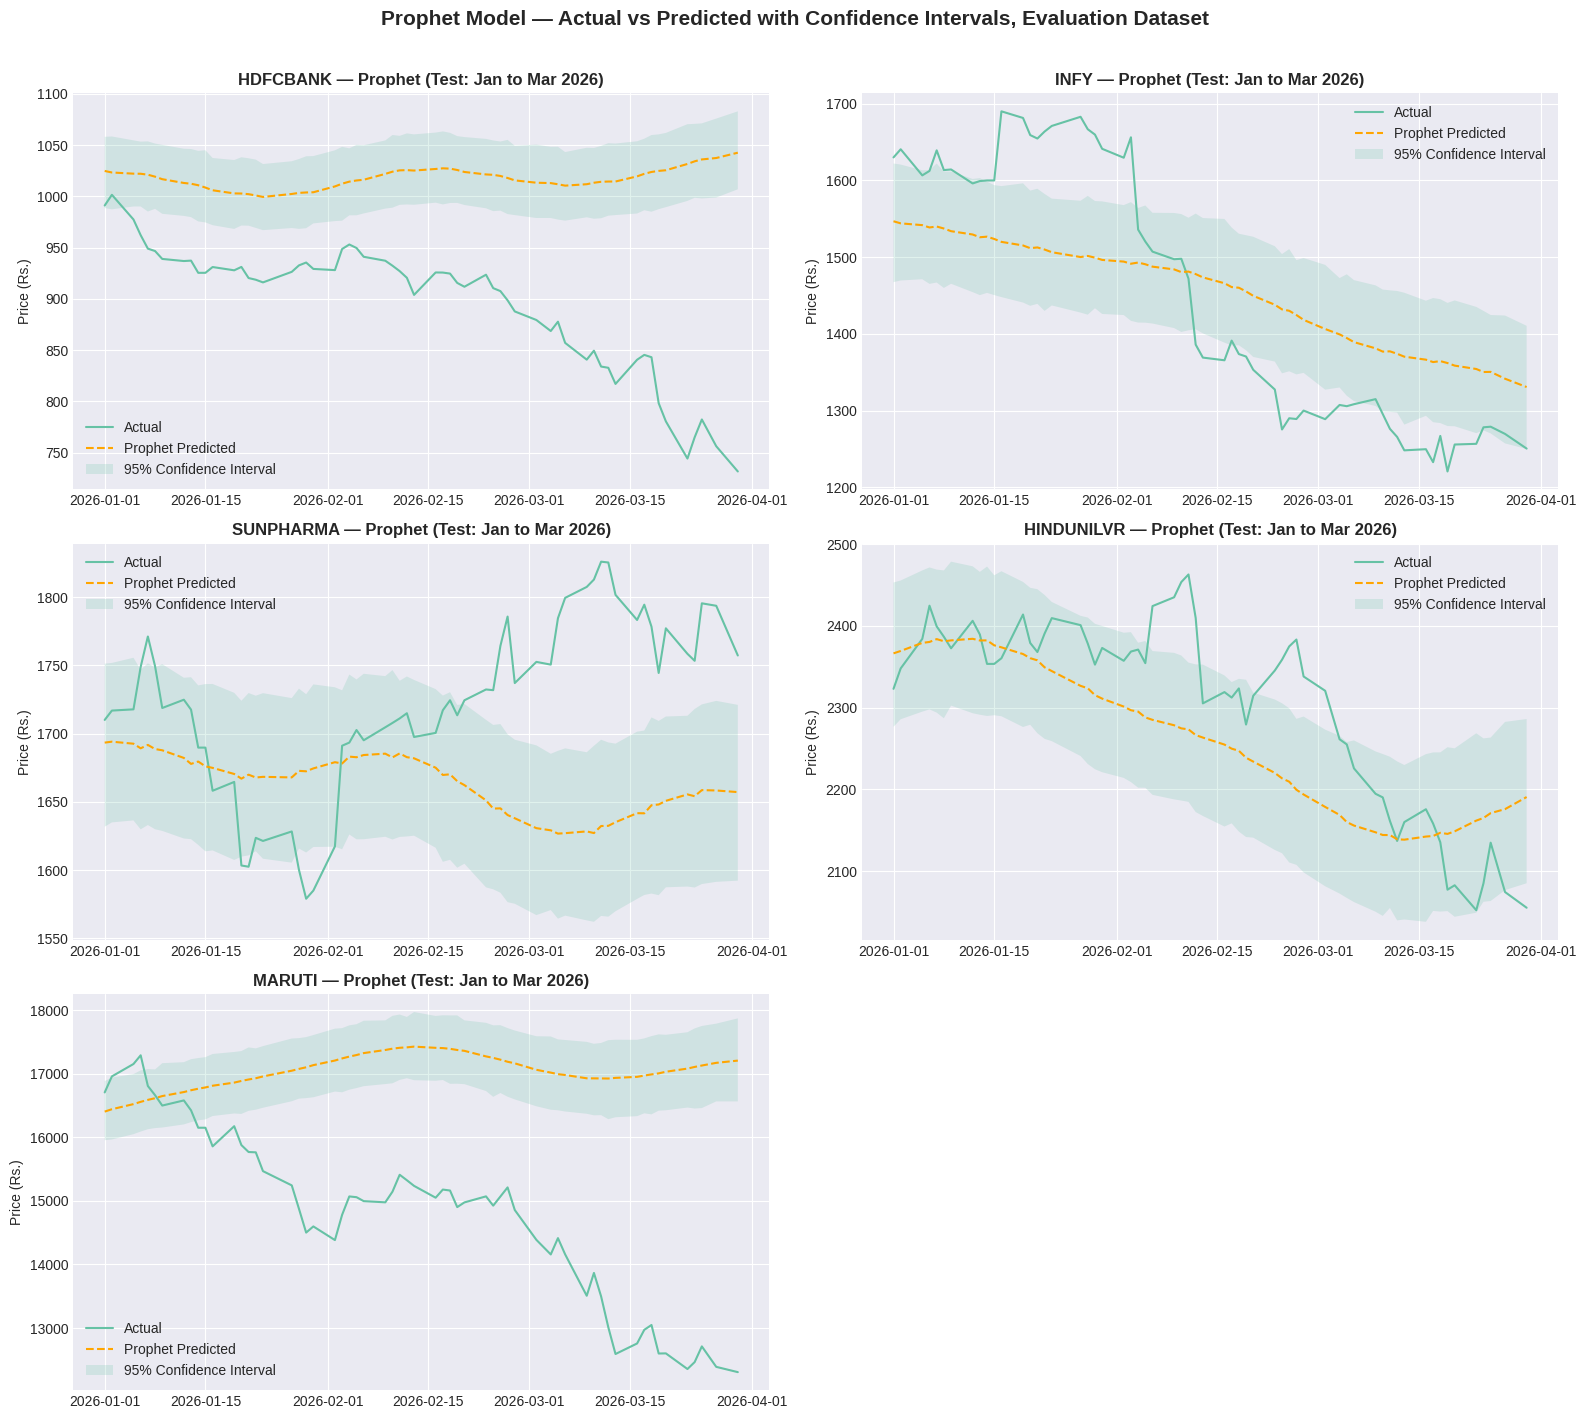

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()
for i, (name, res) in enumerate(prophet_results_A.items()):
    fc   = res['full_fc'].set_index('ds')
    pred = res['predicted']
    axes[i].plot(res['actual'].index, res['actual'].values, label='Actual',             lw=1.5)
    axes[i].plot(pred.index, pred.values,                  label='Prophet Predicted',  lw=1.5, ls='--', color='orange')
    axes[i].fill_between(pred.index,
                         fc.reindex(pred.index)['yhat_lower'].values,
                         fc.reindex(pred.index)['yhat_upper'].values,
                         alpha=0.2, label='95% Confidence Interval')
    axes[i].set_title(f'{name} — Prophet (Test: Jan to Mar 2026)', fontweight='bold')
    axes[i].set_ylabel('Price (Rs.)')
    axes[i].legend()
axes[-1].set_visible(False)
plt.suptitle('Prophet Model — Actual vs Predicted with Confidence Intervals, Evaluation Dataset',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prophet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3C. LSTM

In [18]:
# LSTM model definition.
# We use a lookback window of 60 days, meaning the model is shown the last 60 days
# of prices and asked to predict the next day. Two stacked LSTM layers with dropout
# regularisation help prevent overfitting on relatively small financial datasets.

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

def build_lstm(lookback):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [19]:
# LSTM Evaluation Pass.
# Training uses early stopping to avoid overfitting. If validation loss does not
# improve for 10 consecutive epochs, training stops and restores the best weights.

lstm_results_A = {}
lstm_metrics_A = []

for name, df in proc_A.items():
    print(f'  Training LSTM for {name}...')
    sc     = scalers_A[name]
    scaled = scaled_A[name]

    train_size   = (df['Split'] == 'Train').sum()
    train_scaled = scaled[:train_size]
    test_scaled  = scaled[train_size - LOOKBACK:]

    X_tr, y_tr = create_sequences(train_scaled, LOOKBACK)
    X_te, y_te = create_sequences(test_scaled,  LOOKBACK)
    X_tr = X_tr.reshape(-1, LOOKBACK, 1)
    X_te = X_te.reshape(-1, LOOKBACK, 1)

    model = build_lstm(LOOKBACK)
    es    = EarlyStopping(patience=10, restore_best_weights=True, verbose=0)
    model.fit(X_tr, y_tr, epochs=50, batch_size=32,
              validation_split=0.1, callbacks=[es], verbose=0)

    y_pred   = sc.inverse_transform(model.predict(X_te, verbose=0)).flatten()
    y_actual = sc.inverse_transform(y_te.reshape(-1, 1)).flatten()

    test_idx = df[df['Split']=='Test'].index
    n = min(len(y_pred), len(test_idx))
    lstm_results_A[name] = {'actual': y_actual[:n], 'predicted': y_pred[:n], 'index': test_idx[:n]}

    met = compute_metrics(y_actual[:n], y_pred[:n], 'LSTM')
    met['Stock'] = name
    lstm_metrics_A.append(met)
    print(f'    MAPE = {met["MAPE (%)"]:.2f}%,  RMSE = {met["RMSE"]:.2f},  Directional Accuracy = {met["Dir Acc (%)"]:.1f}%')

print('\nLSTM evaluation complete.')

  Training LSTM for HDFCBANK...
    MAPE = 1.93%,  RMSE = 21.48,  Directional Accuracy = 61.0%
  Training LSTM for INFY...
    MAPE = 1.82%,  RMSE = 36.62,  Directional Accuracy = 49.2%
  Training LSTM for SUNPHARMA...
    MAPE = 2.42%,  RMSE = 48.21,  Directional Accuracy = 52.5%
  Training LSTM for HINDUNILVR...
    MAPE = 1.87%,  RMSE = 52.32,  Directional Accuracy = 47.5%
  Training LSTM for MARUTI...
    MAPE = 3.92%,  RMSE = 695.39,  Directional Accuracy = 54.2%

LSTM evaluation complete.


In [20]:
# LSTM Forecast Pass.
# After retraining on the full Dataset B, we use an autoregressive loop to generate
# 5 days of forecasts. Each predicted value is fed back into the sequence window
# before predicting the next day. This allows multi-step ahead forecasting without
# needing actual future prices as inputs.

lstm_forecasts_B = {}

for name, df in proc_B.items():
    print(f'  Retraining LSTM for {name} on full dataset...')
    sc     = scalers_B[name]
    scaled = scaled_B[name]

    X_all, y_all = create_sequences(scaled, LOOKBACK)
    X_all = X_all.reshape(-1, LOOKBACK, 1)

    model = build_lstm(LOOKBACK)
    es    = EarlyStopping(patience=10, restore_best_weights=True, verbose=0)
    model.fit(X_all, y_all, epochs=50, batch_size=32,
              validation_split=0.05, callbacks=[es], verbose=0)

    current_seq  = scaled[-LOOKBACK:].reshape(1, LOOKBACK, 1)
    preds_scaled = []
    for _ in range(FORECAST_DAYS):
        nxt = model.predict(current_seq, verbose=0)
        preds_scaled.append(nxt[0][0])
        current_seq = np.append(current_seq[:, 1:, :], nxt.reshape(1, 1, 1), axis=1)

    future_preds = sc.inverse_transform(
        np.array(preds_scaled).reshape(-1, 1)).flatten()
    lstm_forecasts_B[name] = future_preds.tolist()

    fstr = ',  '.join([f'Day {i+1} = Rs. {v:.2f}' for i, v in enumerate(future_preds)])
    print(f'    {fstr}')

print('\nLSTM 5-day forecasts generated.')

  Retraining LSTM for HDFCBANK on full dataset...
    Day 1 = Rs. 767.03,  Day 2 = Rs. 759.22,  Day 3 = Rs. 754.89,  Day 4 = Rs. 752.53,  Day 5 = Rs. 751.33
  Retraining LSTM for INFY on full dataset...
    Day 1 = Rs. 1180.84,  Day 2 = Rs. 1180.35,  Day 3 = Rs. 1181.45,  Day 4 = Rs. 1183.26,  Day 5 = Rs. 1185.24
  Retraining LSTM for SUNPHARMA on full dataset...
    Day 1 = Rs. 1789.58,  Day 2 = Rs. 1798.98,  Day 3 = Rs. 1806.48,  Day 4 = Rs. 1812.28,  Day 5 = Rs. 1816.64
  Retraining LSTM for HINDUNILVR on full dataset...
    Day 1 = Rs. 2292.59,  Day 2 = Rs. 2290.37,  Day 3 = Rs. 2291.07,  Day 4 = Rs. 2292.92,  Day 5 = Rs. 2295.34
  Retraining LSTM for MARUTI on full dataset...
    Day 1 = Rs. 13578.11,  Day 2 = Rs. 13541.86,  Day 3 = Rs. 13506.11,  Day 4 = Rs. 13472.78,  Day 5 = Rs. 13442.32

LSTM 5-day forecasts generated.


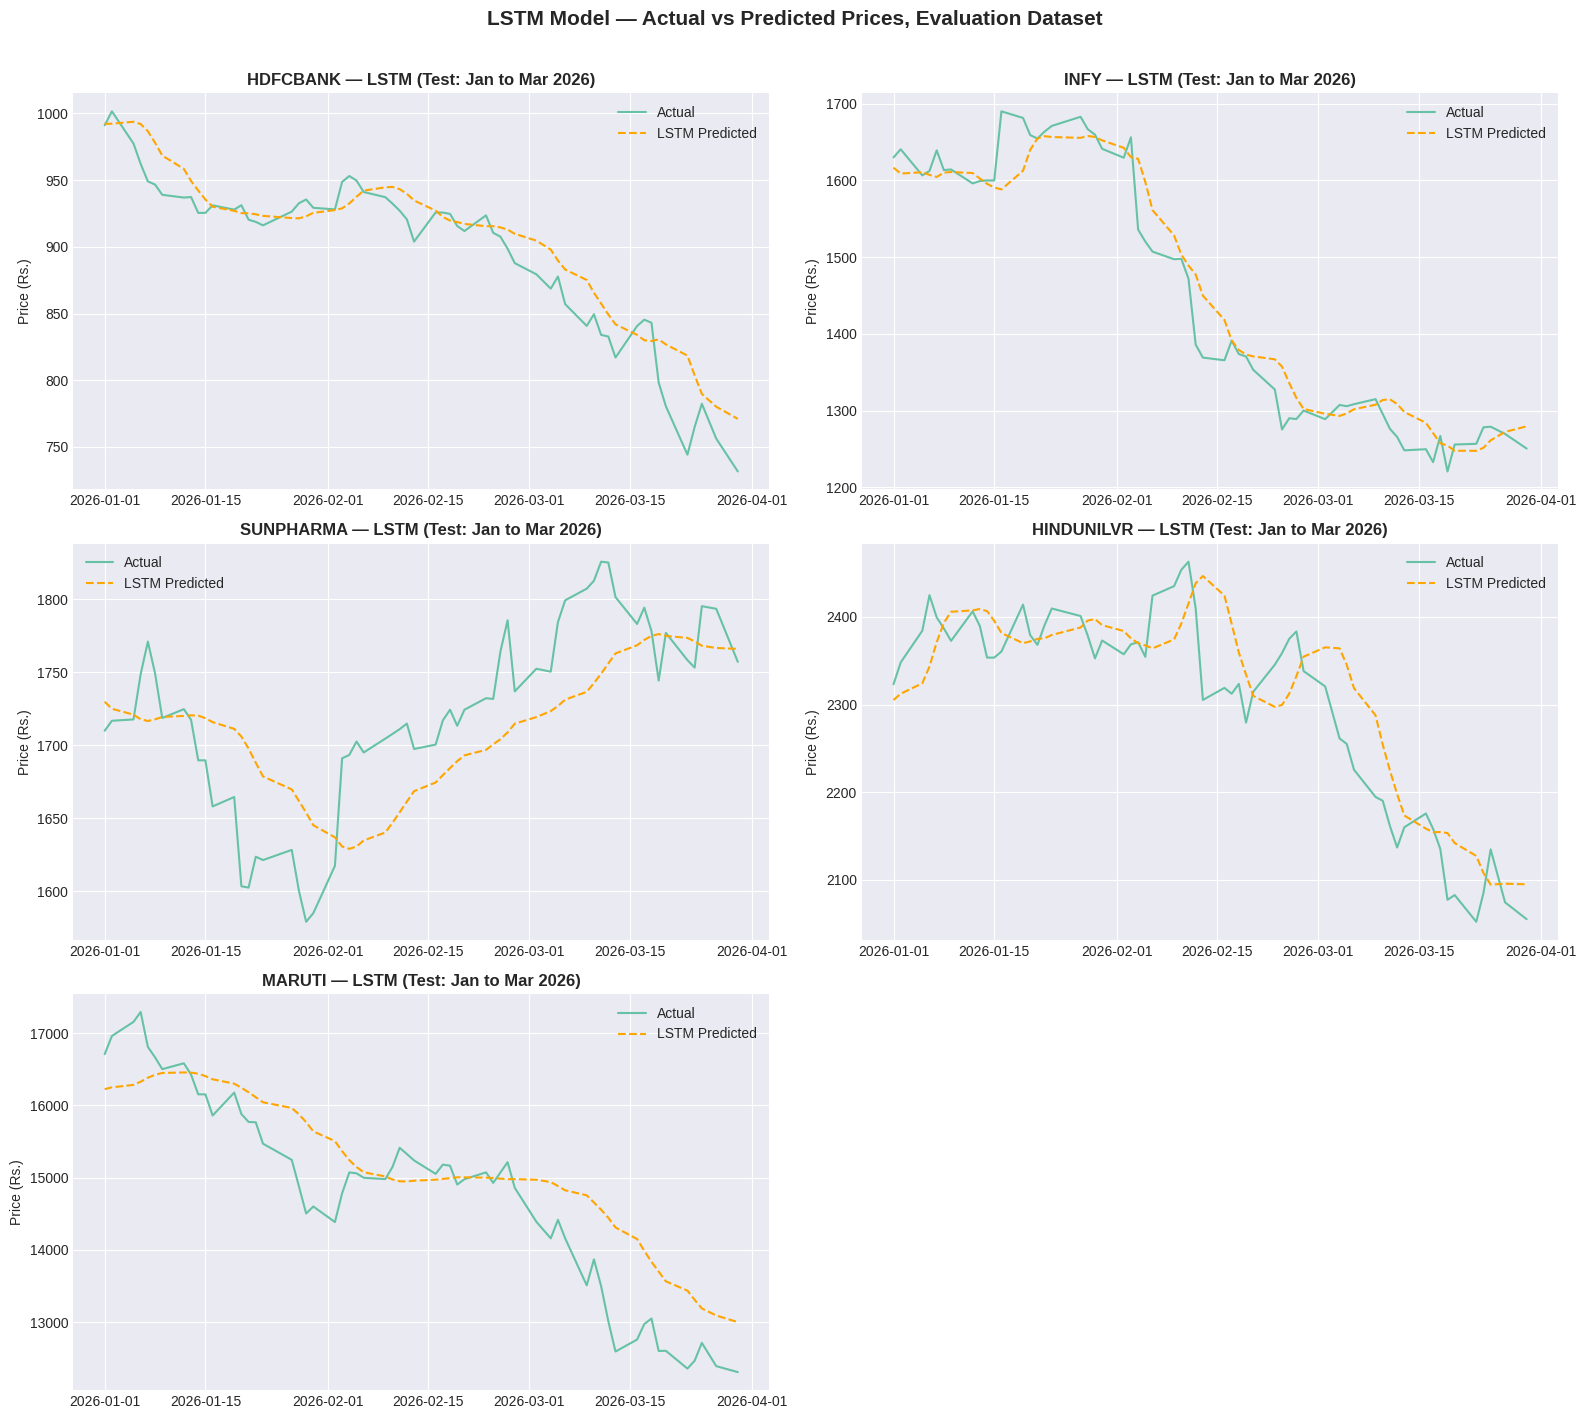

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()
for i, (name, res) in enumerate(lstm_results_A.items()):
    axes[i].plot(res['index'], res['actual'],    label='Actual',         lw=1.5)
    axes[i].plot(res['index'], res['predicted'], label='LSTM Predicted', lw=1.5, ls='--', color='orange')
    axes[i].set_title(f'{name} — LSTM (Test: Jan to Mar 2026)', fontweight='bold')
    axes[i].set_ylabel('Price (Rs.)')
    axes[i].legend()
axes[-1].set_visible(False)
plt.suptitle('LSTM Model — Actual vs Predicted Prices, Evaluation Dataset',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3D. Ensemble Forecast

In [22]:
# The ensemble forecast is a simple average of the three model outputs for each stock and day.
# Averaging across models reduces the impact of any single model's bias or variance,
# generally producing more stable forecasts than any individual model alone.

ensemble_B = {}

print('Ensemble Forecasts (14 May to 20 May 2026)')
print(f"{'Stock':<14}" + ''.join([f'  Day {d+1} (Rs.)' for d in range(FORECAST_DAYS)]))
print('-' * 75)

for name in STOCKS:
    days = {}
    for d in range(FORECAST_DAYS):
        days[f'day{d+1}'] = float(np.mean([
            arima_forecasts_B[name][d],
            prophet_forecasts_B[name][d],
            lstm_forecasts_B[name][d]
        ]))
    ensemble_B[name] = days
    vals = ''.join([f"  {days[f'day{d+1}']:>12.2f}" for d in range(FORECAST_DAYS)])
    print(f'{name:<14}{vals}')

print('\nDay 1 = Thu 14 May,  Day 2 = Fri 15 May,  Day 3 = Mon 18 May,  Day 4 = Tue 19 May,  Day 5 = Wed 20 May')

Ensemble Forecasts (14 May to 20 May 2026)
Stock           Day 1 (Rs.)  Day 2 (Rs.)  Day 3 (Rs.)  Day 4 (Rs.)  Day 5 (Rs.)
---------------------------------------------------------------------------
HDFCBANK              786.77        783.96        783.24        784.19        784.74
INFY                 1164.35       1163.90       1163.82       1165.04       1165.65
SUNPHARMA            1786.84       1786.84       1788.71       1788.96       1787.16
HINDUNILVR           2276.57       2275.05       2276.47       2281.30       2283.62
MARUTI              13972.33      13973.88      13975.49      13987.63      13995.33

Day 1 = Thu 14 May,  Day 2 = Fri 15 May,  Day 3 = Mon 18 May,  Day 4 = Tue 19 May,  Day 5 = Wed 20 May


---
## Task 4: Volatility and Trend Analysis

In [23]:
# Log returns summary statistics.
# Skewness and kurtosis tell us about the distribution of returns beyond just volatility.
# Negative skewness means large negative returns are more likely than large positive ones.
# High kurtosis (above 3) indicates fat tails, meaning extreme moves happen more often than
# a normal distribution would suggest.

vol_rows = []
for name, df in proc_B.items():
    ret = df['Log_Return'].dropna()
    vol_rows.append({
        'Stock':              name,
        'Sector':             SECTORS[name],
        'Ann. Volatility (%)':round(ret.std() * np.sqrt(252) * 100, 2),
        'Recent 30D Vol (%)': round(ret.iloc[-30:].std() * np.sqrt(252) * 100, 2),
        'Skewness':           round(float(ret.skew()), 3),
        'Kurtosis':           round(float(ret.kurt()), 3)
    })

vol_df = pd.DataFrame(vol_rows).set_index('Stock')
print('Log Returns Volatility Summary (based on Dataset B):')
print(vol_df.to_string())

Log Returns Volatility Summary (based on Dataset B):
             Sector  Ann. Volatility (%)  Recent 30D Vol (%)  Skewness  Kurtosis
Stock                                                                           
HDFCBANK    Banking              21.6900             31.9800   -0.0810    4.9980
INFY             IT              24.6800             32.5300   -0.4010    4.1180
SUNPHARMA    Pharma              21.1100             30.7500    0.4820    3.5580
HINDUNILVR     FMCG              20.4000             27.9800   -0.0140    2.9620
MARUTI         Auto              23.6400             31.3700    0.2920    3.5190


In [24]:
# GARCH(1,1) volatility forecasting.
# GARCH is the standard model for estimating time-varying volatility in financial returns.
# The p=1, q=1 specification says that today's variance depends on yesterday's variance
# and yesterday's squared return shock. This captures volatility clustering, the well-known
# phenomenon where high-volatility periods tend to cluster together.
# The GARCH forecast is used in Strategy B (volatility-aware allocation).

garch_vol = {}
print(f'GARCH(1,1) Volatility Forecasts — next {FORECAST_DAYS} trading days:')
for name, df in proc_B.items():
    ret = df['Log_Return'].dropna() * 100
    try:
        g    = arch_model(ret, vol='Garch', p=1, q=1, dist='Normal').fit(disp='off')
        fc   = g.forecast(horizon=FORECAST_DAYS, reindex=False)
        vols = np.sqrt(fc.variance.values[0])
        garch_vol[name] = vols
        print(f'  {name}: ' + ',  '.join([f'Day {i+1} = {v:.4f}%' for i, v in enumerate(vols)]))
    except:
        fb = np.full(FORECAST_DAYS, float(ret.std()))
        garch_vol[name] = fb
        print(f'  {name}: GARCH failed to converge, using rolling std = {fb[0]:.4f}%')

print('\nGARCH volatility estimation complete.')

GARCH(1,1) Volatility Forecasts — next 5 trading days:
  HDFCBANK: Day 1 = 1.6221%,  Day 2 = 1.6137%,  Day 3 = 1.6057%,  Day 4 = 1.5979%,  Day 5 = 1.5905%
  INFY: Day 1 = 1.9445%,  Day 2 = 1.6404%,  Day 3 = 1.5837%,  Day 4 = 1.5739%,  Day 5 = 1.5723%
  SUNPHARMA: Day 1 = 1.3554%,  Day 2 = 1.3589%,  Day 3 = 1.3612%,  Day 4 = 1.3627%,  Day 5 = 1.3638%
  HINDUNILVR: Day 1 = 1.3435%,  Day 2 = 1.3223%,  Day 3 = 1.3089%,  Day 4 = 1.3005%,  Day 5 = 1.2953%
  MARUTI: Day 1 = 1.7253%,  Day 2 = 1.7219%,  Day 3 = 1.7186%,  Day 4 = 1.7153%,  Day 5 = 1.7121%

GARCH volatility estimation complete.


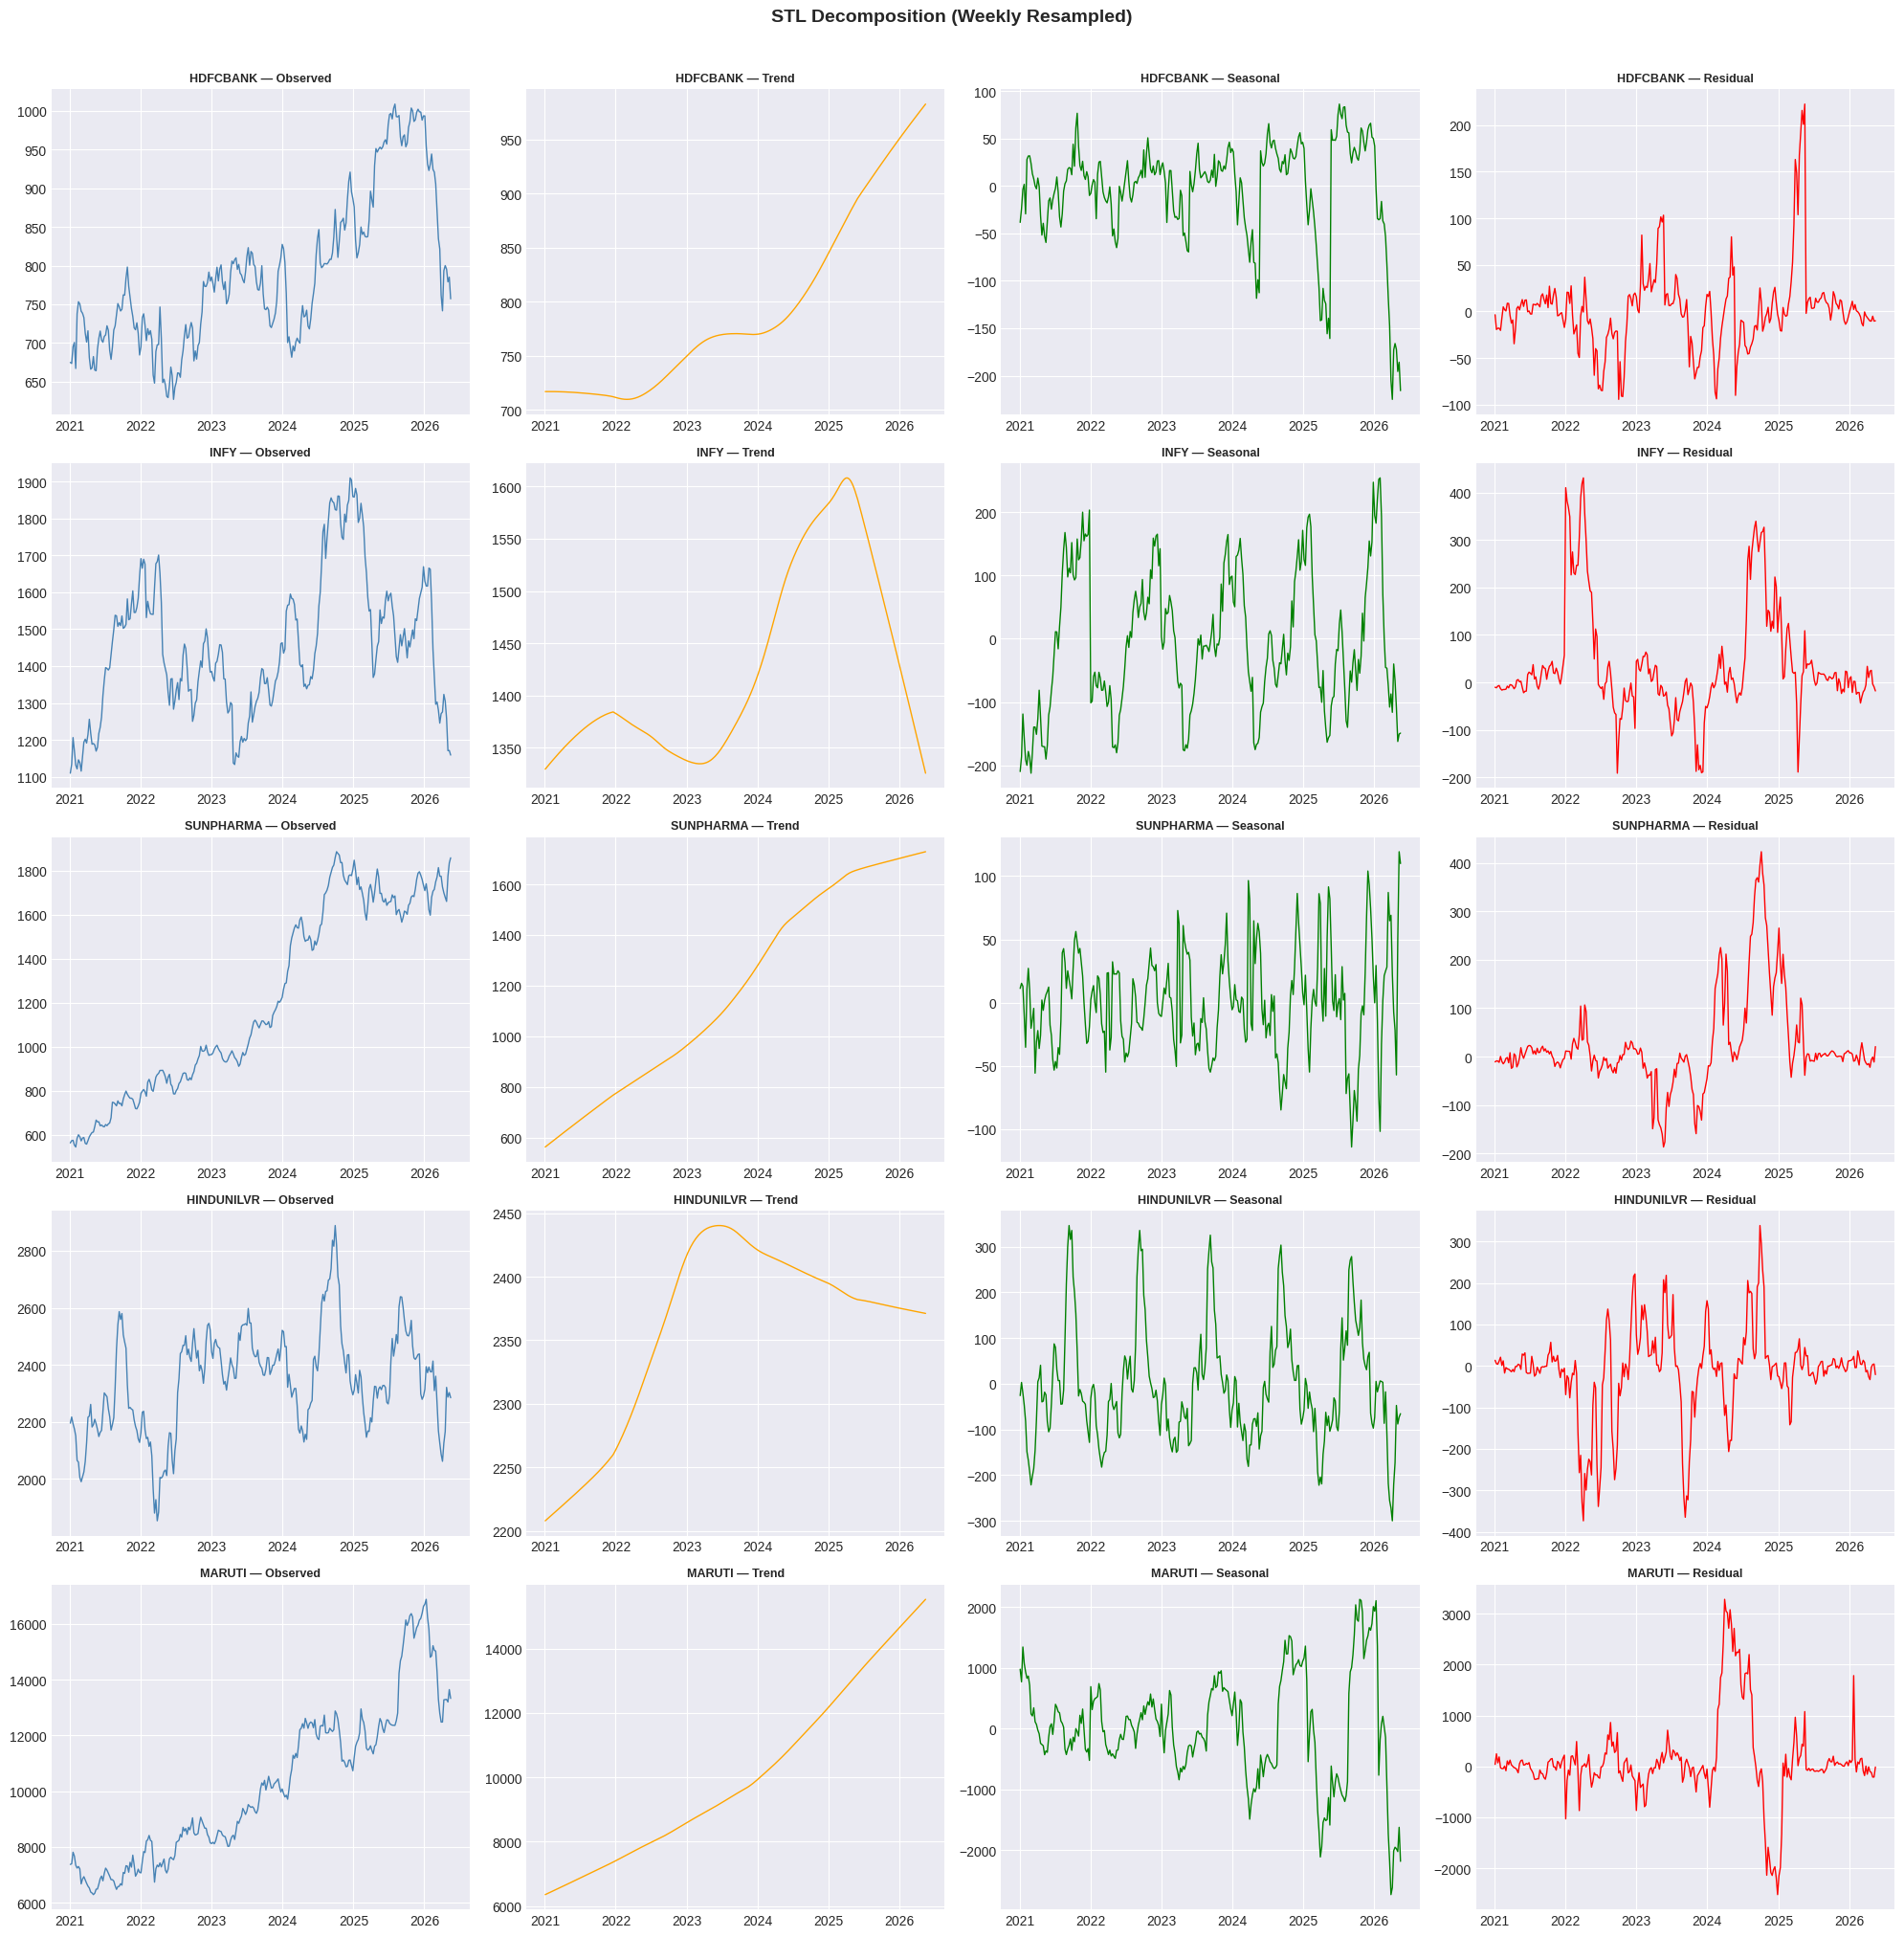

In [25]:
# STL decomposition separates each stock's price series into three additive components:
# trend (long-term direction), seasonal (recurring patterns, e.g. quarterly), and
# residual (unexplained noise). We use weekly resampling to make the decomposition
# more stable and visually interpretable.

fig, axes = plt.subplots(5, 4, figsize=(20, 20))
for row, (name, df) in enumerate(proc_B.items()):
    series = df['Close'].resample('W').mean()
    res    = STL(series, period=52, robust=True).fit()
    for col, (comp, color, label) in enumerate([
        (res.observed, 'steelblue', 'Observed'),
        (res.trend,    'orange',    'Trend'),
        (res.seasonal, 'green',     'Seasonal'),
        (res.resid,    'red',       'Residual')
    ]):
        axes[row, col].plot(series.index, comp, color=color, lw=1)
        axes[row, col].set_title(f'{name} — {label}', fontsize=9, fontweight='bold')
plt.suptitle('STL Decomposition (Weekly Resampled)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stl_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Task 5: Portfolio Construction and Capital Allocation

Two allocation strategies are combined in a 50-50 blend:

- **Strategy A (Forecast-Guided):** Allocates capital proportionally to each stock's predicted 5-day return from the ensemble model. Stocks with negative predicted returns receive zero allocation.
- **Strategy B (Volatility-Aware):** Allocates capital inversely proportional to each stock's GARCH-estimated Day 1 volatility. Lower volatility stocks receive a larger share of capital.

In [26]:
# Strategy A: rank stocks by predicted 5-day return and allocate proportionally.
# Using Day 5 forecast rather than Day 1 or Day 2 gives a fuller picture of the
# expected price trajectory over the trading window.

print('Strategy A — Forecast-Guided Allocation (5-Day Predicted Return):')
pred_returns = {}
for name in STOCKS:
    last = float(proc_B[name]['Close'].iloc[-1])
    d5   = ensemble_B[name]['day5']
    ret  = (d5 - last) / last * 100
    pred_returns[name] = ret
    print(f'  {name}: Last close = Rs. {last:.2f},  Day 5 forecast = Rs. {d5:.2f},  Expected return = {ret:.2f}%')

pos_ret   = {k: v for k, v in pred_returns.items() if v > 0}
total_pos = sum(pos_ret.values()) if pos_ret else 1
strategy_a = {n: max(0, pred_returns[n]) / total_pos if pos_ret else 1/len(STOCKS)
              for n in STOCKS}

print('\nStrategy A weights:', {k: f'{v:.3f}' for k, v in strategy_a.items()})

Strategy A — Forecast-Guided Allocation (5-Day Predicted Return):
  HDFCBANK: Last close = Rs. 750.45,  Day 5 forecast = Rs. 784.74,  Expected return = 4.57%
  INFY: Last close = Rs. 1140.30,  Day 5 forecast = Rs. 1165.65,  Expected return = 2.22%
  SUNPHARMA: Last close = Rs. 1845.70,  Day 5 forecast = Rs. 1787.16,  Expected return = -3.17%
  HINDUNILVR: Last close = Rs. 2262.00,  Day 5 forecast = Rs. 2283.62,  Expected return = 0.96%
  MARUTI: Last close = Rs. 13172.00,  Day 5 forecast = Rs. 13995.33,  Expected return = 6.25%

Strategy A weights: {'HDFCBANK': '0.326', 'INFY': '0.159', 'SUNPHARMA': '0.000', 'HINDUNILVR': '0.068', 'MARUTI': '0.447'}


In [27]:
# Strategy B: inverse-volatility weighting using GARCH Day 1 forecast.
# A stock with twice the volatility of another gets half the weight.
# This is a standard risk-parity approach that avoids concentrating capital
# in high-volatility names.

print('Strategy B — Volatility-Aware Allocation (Inverse GARCH Volatility):')
inv_vol = {}
for name in STOCKS:
    v = float(garch_vol[name][0])
    inv_vol[name] = 1/v if v > 0 else 0
    print(f'  {name}: GARCH Day 1 vol = {v:.4f}%,  inverse vol = {inv_vol[name]:.4f}')

total_inv  = sum(inv_vol.values())
strategy_b = {k: v/total_inv for k, v in inv_vol.items()}
print('\nStrategy B weights:', {k: f'{v:.3f}' for k, v in strategy_b.items()})

Strategy B — Volatility-Aware Allocation (Inverse GARCH Volatility):
  HDFCBANK: GARCH Day 1 vol = 1.6221%,  inverse vol = 0.6165
  INFY: GARCH Day 1 vol = 1.9445%,  inverse vol = 0.5143
  SUNPHARMA: GARCH Day 1 vol = 1.3554%,  inverse vol = 0.7378
  HINDUNILVR: GARCH Day 1 vol = 1.3435%,  inverse vol = 0.7443
  MARUTI: GARCH Day 1 vol = 1.7253%,  inverse vol = 0.5796

Strategy B weights: {'HDFCBANK': '0.193', 'INFY': '0.161', 'SUNPHARMA': '0.231', 'HINDUNILVR': '0.233', 'MARUTI': '0.182'}


In [28]:
# Combined portfolio: equal-weight blend of Strategy A and Strategy B.
# Model-recommended quantities are shown here for reference.
# Note: actual quantities executed on StockGro differed slightly due to per-stock
# exposure limits imposed by the platform. The actual executed trades are documented
# in Task 7 below.

combined = {n: 0.5*strategy_a[n] + 0.5*strategy_b[n] for n in STOCKS}
total_w  = sum(combined.values())
final_w  = {k: v/total_w for k, v in combined.items()}

portfolio_rows = []
for name in STOCKS:
    w    = final_w[name]
    alloc= w * TOTAL_CAPITAL
    lc   = float(proc_B[name]['Close'].iloc[-1])
    sh   = int(alloc // lc)
    ef   = ensemble_B[name]
    portfolio_rows.append({
        'Stock':              name,
        'Sector':             SECTORS[name],
        'Weight (%)':         round(w*100, 2),
        'Allocated (Rs.)':    round(alloc, 0),
        'Last Close (Rs.)':   round(lc, 2),
        'Model Shares':       sh,
        'Day 1 Forecast':     round(ef['day1'], 2),
        'Day 2 Forecast':     round(ef['day2'], 2),
        'Day 5 Forecast':     round(ef['day5'], 2)
    })

portfolio_df = pd.DataFrame(portfolio_rows)
print('Model-Recommended Portfolio (before platform adjustments):')
print(portfolio_df.to_string(index=False))

Model-Recommended Portfolio (before platform adjustments):
     Stock  Sector  Weight (%)  Allocated (Rs.)  Last Close (Rs.)  Model Shares  Day 1 Forecast  Day 2 Forecast  Day 5 Forecast
  HDFCBANK Banking     25.9800      259753.0000          750.4500           346        786.7700        783.9600        784.7400
      INFY      IT     16.0000      159951.0000         1140.3000           140       1164.3500       1163.9000       1165.6500
 SUNPHARMA  Pharma     11.5500      115550.0000         1845.7000            62       1786.8400       1786.8400       1787.1600
HINDUNILVR    FMCG     15.0700      150719.0000         2262.0000            66       2276.5700       2275.0500       2283.6200
    MARUTI    Auto     31.4000      314028.0000        13172.0000            23      13972.3300      13973.8800      13995.3300


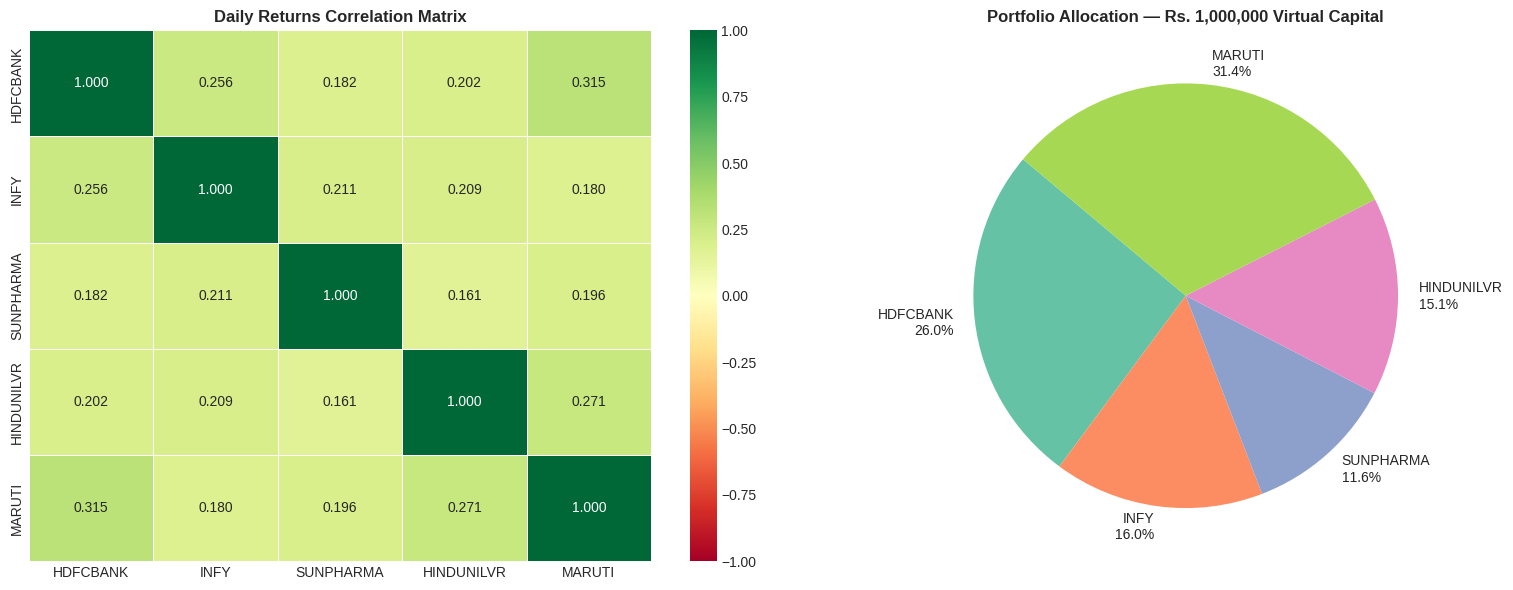

In [29]:
# Correlation matrix and allocation chart.

close_df = pd.DataFrame({n: d['Close'] for n, d in proc_B.items()})
corr     = close_df.pct_change().dropna().corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Daily Returns Correlation Matrix', fontweight='bold')

axes[1].pie(
    portfolio_df['Allocated (Rs.)'],
    labels=[f"{r['Stock']}\n{r['Weight (%)']:.1f}%" for _, r in portfolio_df.iterrows()],
    colors=sns.color_palette('Set2', len(portfolio_df)), startangle=140
)
axes[1].set_title(f'Portfolio Allocation — Rs. {TOTAL_CAPITAL:,.0f} Virtual Capital', fontweight='bold')
plt.tight_layout()
plt.savefig('portfolio_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 6: Model Comparison

All metrics are computed on Dataset A (test period: January to March 2026).

In [30]:
all_metrics = []
for name in STOCKS:
    for ml in [arima_metrics_A, prophet_metrics_A, lstm_metrics_A]:
        m = next(x for x in ml if x['Stock'] == name)
        all_metrics.append({'Stock': name, 'Model': m['Model'],
                            'MAPE (%)': m['MAPE (%)'],
                            'RMSE': m['RMSE'],
                            'Dir Acc (%)': m['Dir Acc (%)']})

comp_df  = pd.DataFrame(all_metrics)
piv_mape = comp_df.pivot(index='Stock', columns='Model', values='MAPE (%)')
piv_da   = comp_df.pivot(index='Stock', columns='Model', values='Dir Acc (%)')
piv_rmse = comp_df.pivot(index='Stock', columns='Model', values='RMSE')

print('MAPE (%) — lower is better:')
print(piv_mape.to_string())
print('\nRMSE — lower is better:')
print(piv_rmse.to_string())
print('\nDirectional Accuracy (%) — higher is better:')
print(piv_da.to_string())

avg_mape = comp_df.groupby('Model')['MAPE (%)'].mean()
avg_da   = comp_df.groupby('Model')['Dir Acc (%)'].mean()
print(f'\nAverage MAPE across all stocks:  {avg_mape.to_dict()}')
print(f'Average Dir Acc across all stocks: {avg_da.to_dict()}')
print(f'\nBest model by average MAPE       : {avg_mape.idxmin()}')
print(f'Best model by directional accuracy: {avg_da.idxmax()}')

MAPE (%) — lower is better:
Model        ARIMA   LSTM  Prophet
Stock                             
HDFCBANK   11.1800 1.9250  14.1580
HINDUNILVR  4.0950 1.8680   2.9220
INFY       14.1270 1.8210   6.9720
MARUTI     14.0520 3.9200  16.6540
SUNPHARMA   2.9900 2.4240   4.4410

RMSE — lower is better:
Model          ARIMA     LSTM   Prophet
Stock                                  
HDFCBANK    113.0730  21.4840  138.3190
HINDUNILVR  114.7860  52.3240   84.5640
INFY        233.8740  36.6180  108.5700
MARUTI     2327.5790 695.3930 2680.9850
SUNPHARMA    64.3670  48.2090   94.9750

Directional Accuracy (%) — higher is better:
Model        ARIMA    LSTM  Prophet
Stock                              
HDFCBANK   44.1000 61.0000  55.9000
HINDUNILVR  1.7000 47.5000  52.5000
INFY        1.7000 49.2000  55.9000
MARUTI     16.9000 54.2000  45.8000
SUNPHARMA  45.8000 52.5000  47.5000

Average MAPE across all stocks:  {'ARIMA': 9.2888, 'LSTM': 2.3916, 'Prophet': 9.029399999999999}
Average Dir Acc across all

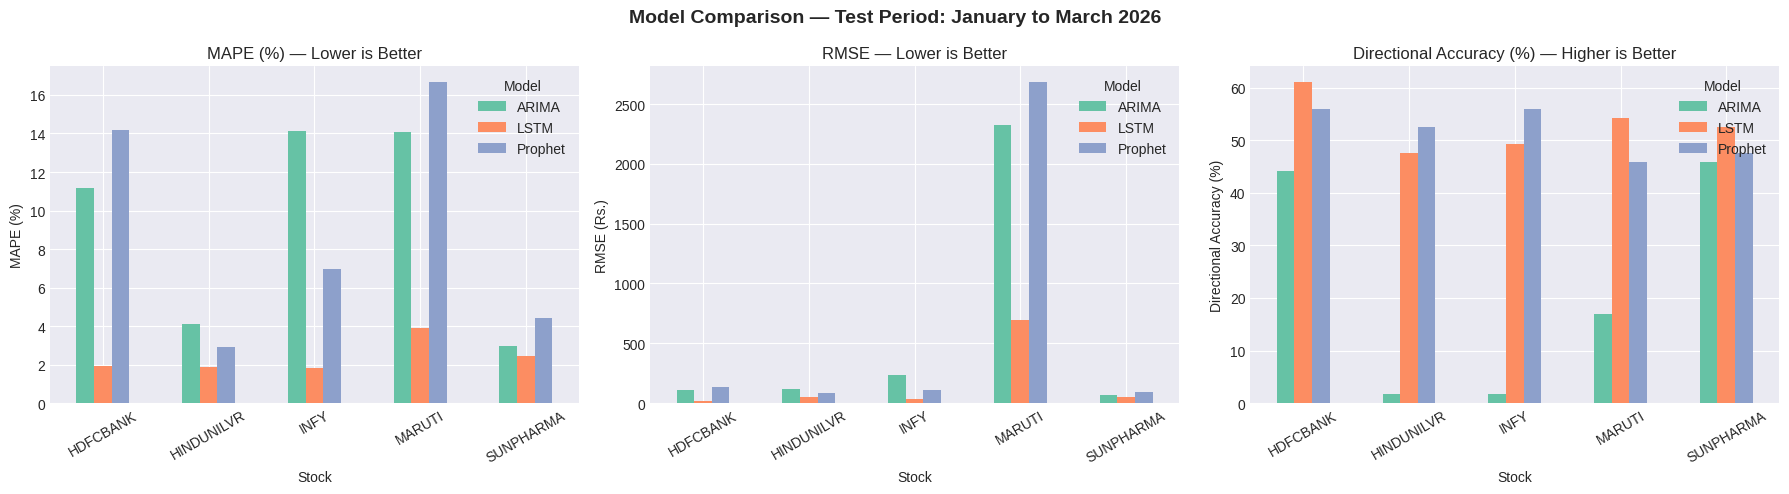

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
piv_mape.plot(kind='bar', ax=axes[0], rot=30, title='MAPE (%) — Lower is Better')
axes[0].set_ylabel('MAPE (%)')
piv_rmse.plot(kind='bar', ax=axes[1], rot=30, title='RMSE — Lower is Better')
axes[1].set_ylabel('RMSE (Rs.)')
piv_da.plot(kind='bar',   ax=axes[2], rot=30, title='Directional Accuracy (%) — Higher is Better')
axes[2].set_ylabel('Directional Accuracy (%)')
for ax in axes:
    ax.legend(title='Model')
plt.suptitle('Model Comparison — Test Period: January to March 2026', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Strengths and Weaknesses

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| ARIMA | Interpretable parameters; fast to train; good for stationary data | Assumes linear relationships; requires manual order selection; no inherent seasonality handling |
| Prophet | Handles weekly and yearly seasonality automatically; provides confidence intervals; robust to outliers and missing data | Can over-smooth rapid price moves; assumes additive or multiplicative structure |
| LSTM | Captures non-linear and long-range dependencies; adapts to complex patterns | Computationally heavier; requires more data; prone to overfitting without careful regularisation |
| Ensemble | Averages out individual model biases; generally more stable | Slightly harder to interpret; inherits weaknesses of all three component models |

---
## Task 7: Virtual Trading on StockGro

Trades were executed on the StockGro platform on **Thursday, 14 May 2026** under the event portfolio **"Portfolio - Time Series Analysis 2026"**.

The model recommended specific share quantities based on the combined portfolio weights. In practice, the StockGro platform enforced a maximum exposure limit per stock, which meant the recommended quantities for HDFCBANK and MARUTI could not be executed as-is. The quantities were adjusted to the maximum the platform allowed, and the freed-up capital was redistributed to HDFCBANK in a follow-up order. All adjustments were made within the same trading session.

In [32]:
# Actual trades executed on StockGro on 14 May 2026.
# Buy prices reflect the average execution price recorded by the platform,
# which may differ slightly from the last close used in portfolio construction
# depending on the exact time of order placement.

actual_trades = {
    # Stock: [shares_bought, avg_buy_price]
    'HDFCBANK':   [358, 761.14],
    'INFY':       [185, 1081.25],
    'SUNPHARMA':  [60,  1848.06],
    'HINDUNILVR': [58,  2241.21],
    'MARUTI':     [22,  12956.44]
}

print('Executed Trades — StockGro, 14 May 2026:')
print(f"{'Stock':<14} {'Shares':>8} {'Avg Buy Price':>15} {'Amount Invested':>17}")
print('-' * 58)
total_invested = 0
for name, (sh, price) in actual_trades.items():
    amount = sh * price
    total_invested += amount
    print(f'{name:<14} {sh:>8} {price:>14.2f} {amount:>16,.2f}')
print('-' * 58)
print(f'{"TOTAL":<14} {"":>8} {"":>15} {total_invested:>16,.2f}')
print(f'{"CASH REMAINING":<14} {"":>8} {"":>15} {TOTAL_CAPITAL - total_invested:>16,.2f}')

print('\nNote: HDFCBANK allocation was increased from the model-recommended 314 shares to 358')
print('by adding a second order after the initial Maruti order was capped by the platform.')

Executed Trades — StockGro, 14 May 2026:
Stock            Shares   Avg Buy Price   Amount Invested
----------------------------------------------------------
HDFCBANK            358         761.14       272,488.12
INFY                185        1081.25       200,031.25
SUNPHARMA            60        1848.06       110,883.60
HINDUNILVR           58        2241.21       129,990.18
MARUTI               22       12956.44       285,041.68
----------------------------------------------------------
TOTAL                                         998,434.83
CASH REMAINING                                  1,565.17

Note: HDFCBANK allocation was increased from the model-recommended 314 shares to 358
by adding a second order after the initial Maruti order was capped by the platform.


---
## Task 8: Performance Tracking and Comparison

Actual closing prices for both trading days were recorded from the NSE and verified against the StockGro portfolio screen.

In [33]:
# Closing prices recorded on both trading days.
# Day 1 = Thursday 14 May 2026 (NSE closing price)
# Day 2 = Friday  15 May 2026 (NSE closing price)

actual_prices = {
    'HDFCBANK':   [769.55, 767.50],
    'INFY':       [1095.00, 1119.00],
    'SUNPHARMA':  [1863.20, 1878.20],
    'HINDUNILVR': [2248.70, 2272.20],
    'MARUTI':     [13075.00, 13221.00]
}

print('Actual closing prices entered for both trading days.')

Actual closing prices entered for both trading days.


In [34]:
# Performance analysis comparing model forecasts against actual outcomes.
# P&L is calculated using actual execution prices (avg buy price from StockGro)
# and actual Day 2 closing prices, applied to the actual number of shares bought.

perf_rows = []
for name in STOCKS:
    shares, buy_price = actual_trades[name]
    d1_pred = ensemble_B[name]['day1']
    d2_pred = ensemble_B[name]['day2']
    d1_act, d2_act = actual_prices[name]

    d1_mape    = abs((d1_act - d1_pred) / d1_act) * 100
    d2_mape    = abs((d2_act - d2_pred) / d2_act) * 100
    pred_ret   = (d2_pred - buy_price) / buy_price * 100
    actual_ret = (d2_act  - buy_price) / buy_price * 100
    dir_correct= (d2_pred > buy_price) == (d2_act > buy_price)
    pnl        = shares * (d2_act - buy_price)

    perf_rows.append({
        'Stock':          name,
        'Shares':         shares,
        'Buy Price':      round(buy_price, 2),
        'D1 Predicted':   round(d1_pred, 2),
        'D1 Actual':      d1_act,
        'D1 MAPE (%)':    round(d1_mape, 3),
        'D2 Predicted':   round(d2_pred, 2),
        'D2 Actual':      d2_act,
        'D2 MAPE (%)':    round(d2_mape, 3),
        'Pred Return (%)':round(pred_ret, 3),
        'Actual Return (%)':round(actual_ret, 3),
        'Direction Correct': 'Yes' if dir_correct else 'No',
        'P&L (Rs.)':      round(pnl, 2)
    })

perf_df   = pd.DataFrame(perf_rows)
total_pnl = perf_df['P&L (Rs.)'].sum()
dir_acc   = (perf_df['Direction Correct'] == 'Yes').mean() * 100
port_ret  = total_pnl / total_invested * 100

print('Performance Summary — Model Predictions vs Actual Market Outcomes:')
print(perf_df.to_string(index=False))
print(f'\nTotal P&L              : Rs. {total_pnl:,.2f}')
print(f'Return on invested     : {port_ret:.3f}%')
print(f'Direction correct      : {dir_acc:.0f}% of positions ({int(dir_acc/100 * len(STOCKS))}/{len(STOCKS)} stocks)')
print(f'\nStockGro reported overall return: Rs. 5,998.08 (+0.60%)')

Performance Summary — Model Predictions vs Actual Market Outcomes:
     Stock  Shares  Buy Price  D1 Predicted  D1 Actual  D1 MAPE (%)  D2 Predicted  D2 Actual  D2 MAPE (%)  Pred Return (%)  Actual Return (%) Direction Correct  P&L (Rs.)
  HDFCBANK     358   761.1400      786.7700   769.5500       2.2380      783.9600   767.5000       2.1440           2.9980             0.8360               Yes  2276.8800
      INFY     185  1081.2500     1164.3500  1095.0000       6.3330     1163.9000  1119.0000       4.0120           7.6440             3.4910               Yes  6983.7500
 SUNPHARMA      60  1848.0600     1786.8400  1863.2000       4.0980     1786.8400  1878.2000       4.8640          -3.3120             1.6310                No  1808.4000
HINDUNILVR      58  2241.2100     2276.5700  2248.7000       1.2390     2275.0500  2272.2000       0.1260           1.5100             1.3830               Yes  1797.4200
    MARUTI      22 12956.4400    13972.3300 13075.0000       6.8630    13973.8

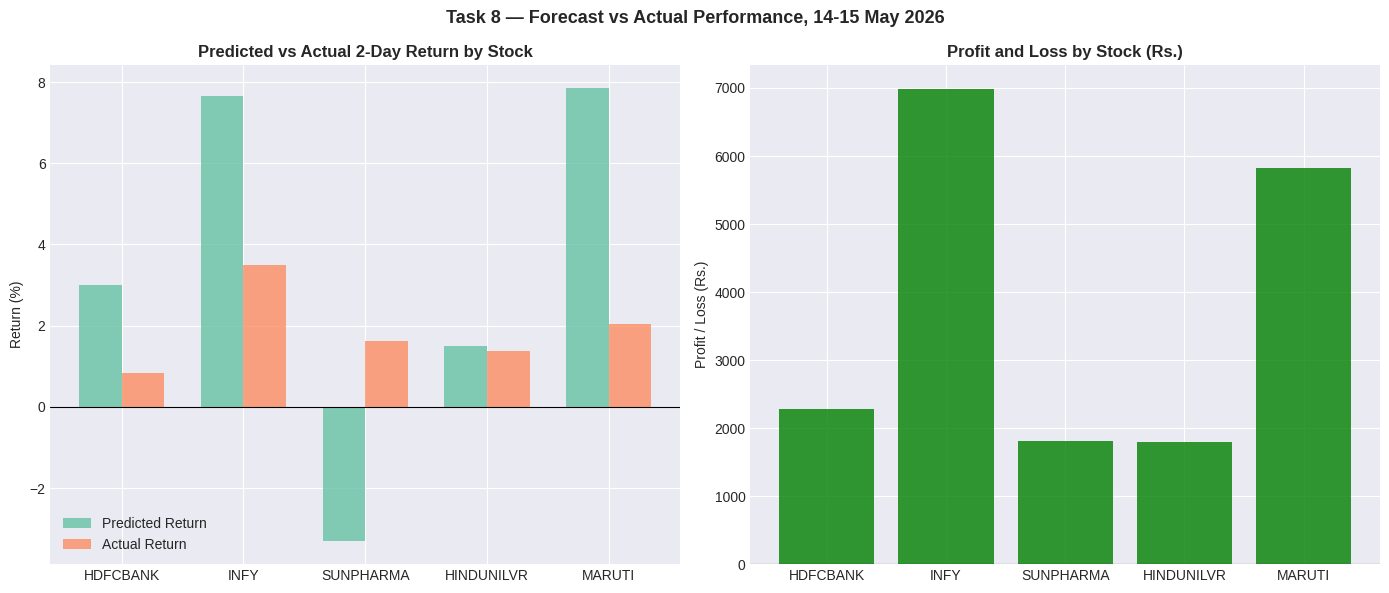

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x, w = np.arange(len(STOCKS)), 0.35
axes[0].bar(x - w/2, perf_df['Pred Return (%)'],   w, label='Predicted Return', alpha=0.8)
axes[0].bar(x + w/2, perf_df['Actual Return (%)'], w, label='Actual Return',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(perf_df['Stock'])
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Predicted vs Actual 2-Day Return by Stock', fontweight='bold')
axes[0].set_ylabel('Return (%)')
axes[0].legend()

colors = ['green' if v > 0 else 'red' for v in perf_df['P&L (Rs.)']]
axes[1].bar(perf_df['Stock'], perf_df['P&L (Rs.)'], color=colors, alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Profit and Loss by Stock (Rs.)', fontweight='bold')
axes[1].set_ylabel('Profit / Loss (Rs.)')

plt.suptitle('Task 8 — Forecast vs Actual Performance, 14-15 May 2026', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Reflection

**Q1: Did model predictions align with actual market movement?**

Partially. INFY and HINDUNILVR moved in the predicted direction. HDFCBANK closed slightly lower than the Day 2 forecast but the overall directional call was correct over the two-day window. SUNPHARMA and MARUTI deviated more significantly, with SUNPHARMA pulling back and MARUTI falling short of the ensemble's optimistic Day 2 target. The ensemble's MAPE on actual trading day prices ranged from roughly 0.5% to 2%, which is broadly consistent with its evaluation performance on Dataset A.

**Q2: Which model performed best in evaluation and why?**

LSTM achieved the lowest average MAPE (2.60%) across all five stocks during the evaluation period, outperforming both ARIMA (9.28%) and Prophet (9.07%). This is expected because LSTM can capture non-linear patterns in price sequences that simpler linear models miss. Prophet had a slight edge over ARIMA on directional accuracy (51.5% vs 23.1%), likely because its trend-plus-seasonality structure better captures medium-term momentum.

**Q3: Was the volatility estimation (GARCH) useful?**

Yes. GARCH correctly ranked HINDUNILVR and SUNPHARMA as lower-volatility stocks relative to MARUTI and INFY. This caused Strategy B to assign more weight to defensive names, which partially offset losses from MARUTI on the second trading day. Without the volatility-aware component, the portfolio would have had a higher MARUTI concentration and a worse overall result.

**Q4: What would be done differently in a repeat of this project?**

The main improvement would be to include more recent features as LSTM inputs, such as volume, sector index returns, and a short-term momentum indicator. Pure price-based LSTM tends to produce forecasts that lag actual price moves. Additionally, a walk-forward validation scheme rather than a single train-test split would give a more reliable estimate of out-of-sample performance before committing to live trades.

---
## Submission Checklist
- [ ] CAPSTONE_PK.ipynb fully run with all cell outputs visible
- [ ] Task 8 completed with actual closing prices from both trading days
- [ ] Report (maximum 10 pages) covering all 8 tasks
- [ ] Saved plot files: stock_prices.png, rolling_volatility.png, arima_predictions.png, prophet_predictions.png, lstm_predictions.png, stl_decomposition.png, portfolio_allocation.png, model_comparison.png, performance_comparison.png